# Smart Hospital – Project 3: ICU Intelligent Monitoring
## Multimodal Data Analysis and Mortality Prediction in Intensive Care

**Course**: Smart Hospital – Politecnico di Milano  
**Dataset**: Synthetic dataset inspired by MIMIC-III (long-format, multi-timestep)  
**Goal**: Build an end-to-end AI pipeline for ICU mortality prediction — from EDA to explainable AI.

---
### Notebook Structure
| Section | Content |
|---------|---------|
| 1 | Setup & Dependencies |
| 2 | Dataset Loading & Overview |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | 20 Representative Patients |
| 5 | Temporal Sequence Analysis |
| 6 | Feature Engineering (NEWS2, interaction features) |
| 7 | AI Models: XGBoost + 1D-CNN + Ensemble |
| 8 | Alert Threshold Selection |
| 9 | Explainability: SHAP and LIME |
| 10 | Student Tasks |


## Section 1 – Setup and Dependencies

> Run this cell once at the beginning of each Colab session.


In [1]:
!pip install shap lime xgboost imbalanced-learn -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import lime
import lime.lime_tabular

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, GlobalMaxPooling1D,
                                      Dense, Dropout, Concatenate, Masking)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Feature groups (temporal vitals measured at each ICU timestep)
VITAL_COLS = ['hr', 'rr', 'sbp', 'temperature', 'spo2', 'gcs']
LAB_COLS   = ['lactate', 'creatinine', 'wbc', 'troponin']
WEAK_COLS  = ['sodium', 'potassium', 'glucose']  # lower signal-to-noise
ALL_TEMPORAL = VITAL_COLS + LAB_COLS + WEAK_COLS

STATIC_COLS  = ['age', 'bmi', 'sex', 'diagnosis', 'admission_type', 'icu_los']
TARGET       = 'mortality_label'

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
print("✅ Libraries loaded  |  TF", tf.__version__, " | Seed =", SEED)


2026-05-12 13:07:35.000426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778591255.222818      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778591255.291071      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778591255.847048      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778591255.847140      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778591255.847145      57 computation_placer.cc:177] computation placer alr

✅ Libraries loaded  |  TF 2.19.0  | Seed = 42


## Section 2 – Dataset Loading and Overview

### Clinical Context
The dataset is a synthetic cohort inspired by **MIMIC-III** (Medical Information Mart for Intensive Care), a freely accessible critical care database from Beth Israel Deaconess Medical Center.

Each patient has **2–5 timestep measurements** (sequential ICU observations), plus static demographics and lab values.

**Dataset structure (long format):**
```
patient_id | timestep | diagnosis | sex | age | hr | rr | sbp | ... | mortality_label
     0     |    0     |  Sepsis   |  M  | 72  | 98 | 24 | 88 | ... |      1
     0     |    1     |  Sepsis   |  M  | 72  |102 | 26 | 82 | ... |      1
     1     |    0     |  ARDS     |  F  | 58  | 75 | 18 |118 | ... |      0
```


In [3]:
# ─── LOAD DATASET ──────────────────────────────────────────────────────────
# Option 1: Manual upload in Colab

# Option 2: Google Drive mount
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Mimic_Multimodal.csv')

# Option 3: Direct path (default – expects the CSV in ../data/, see data/README.md)
CSV_PATH = '../data/dataset.csv'  # 🔧 Change to your path if needed
df = pd.read_csv(CSV_PATH)

# Drop teacher-only column (severity_score used only for dataset generation)
if 'severity_score' in df.columns:
    df = df.drop(columns=['severity_score'])

print(f"{'='*55}")
print(f"  DATASET OVERVIEW")
print(f"{'='*55}")
n_pts = df['patient_id'].nunique()
mort  = df.groupby('patient_id')[TARGET].first().mean()
print(f"  Total patients        : {n_pts:>6}")
print(f"  Total observations    : {len(df):>6}")
print(f"  Features              : {len(df.columns):>6}")
print(f"  Mortality rate        : {mort*100:>5.1f}%")
print(f"  Age mean ± std        : {df['age'].mean():.1f} ± {df['age'].std():.1f} years")
print(f"  ICU stay (median)     : {df['icu_los'].median():.1f} days")
print(f"  Timesteps per patient : {df.groupby('patient_id').size().describe()[['min','50%','max']].to_dict()}")
print(f"{'='*55}")
df.head(6)


  DATASET OVERVIEW
  Total patients        :    500
  Total observations    :   1717
  Features              :     22
  Mortality rate        :  12.6%
  Age mean ± std        : 65.8 ± 13.7 years
  ICU stay (median)     : 2.7 days
  Timesteps per patient : {'min': 2.0, '50%': 3.5, 'max': 5.0}


,patient_id,timestep,diagnosis,sex,age,bmi,admission_type,hr,rr,sbp,...,gcs,lactate,creatinine,wbc,troponin,sodium,potassium,glucose,icu_los,mortality_label
0,0,0,Stroke,F,75,25.1,Emergency,104.1,27.8,90.0,...,10,5.93,3.28,10.4,0.494,134.1,5.12,137.0,9.86,0
1,0,1,Stroke,F,75,25.1,Emergency,101.6,28.0,92.5,...,10,6.11,3.40,12.5,0.504,132.3,5.36,146.1,9.86,0
2,0,2,Stroke,F,75,25.1,Emergency,106.9,27.9,79.5,...,9,5.94,3.67,10.3,0.508,128.5,5.05,147.1,9.86,0
3,1,0,AKI,F,74,24.2,Emergency,104.3,23.5,94.0,...,10,5.12,2.19,11.9,0.413,133.4,4.92,115.2,8.61,1
4,1,1,AKI,F,74,24.2,Emergency,100.4,25.3,87.5,...,11,4.89,2.48,16.5,0.397,136.3,4.87,118.3,8.61,1
5,1,2,AKI,F,74,24.2,Emergency,95.4,23.0,86.1,...,9,5.69,2.51,12.7,0.473,135.9,5.21,132.6,8.61,1


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Data types:")
print(df.dtypes)


Missing values per column:
patient_id         0
timestep           0
diagnosis          0
sex                0
age                0
bmi                0
admission_type     0
hr                 0
rr                 0
sbp                0
temperature        0
spo2               0
gcs                0
lactate            0
creatinine         0
wbc                0
troponin           0
sodium             0
potassium          0
glucose            0
icu_los            0
mortality_label    0
dtype: int64

Data types:
patient_id           int64
timestep             int64
diagnosis           object
sex                 object
age                  int64
bmi                float64
admission_type      object
hr                 float64
rr                 float64
sbp                float64
temperature        float64
spo2               float64
gcs                  int64
lactate            float64
creatinine         float64
wbc                float64
troponin           float64
sodium             float64

## Section 3 – Exploratory Data Analysis (EDA)

We explore the distribution of patients, pathologies, vital signs, and their relationship with in-hospital mortality.


### 3.1 – Demographic distribution and outcomes

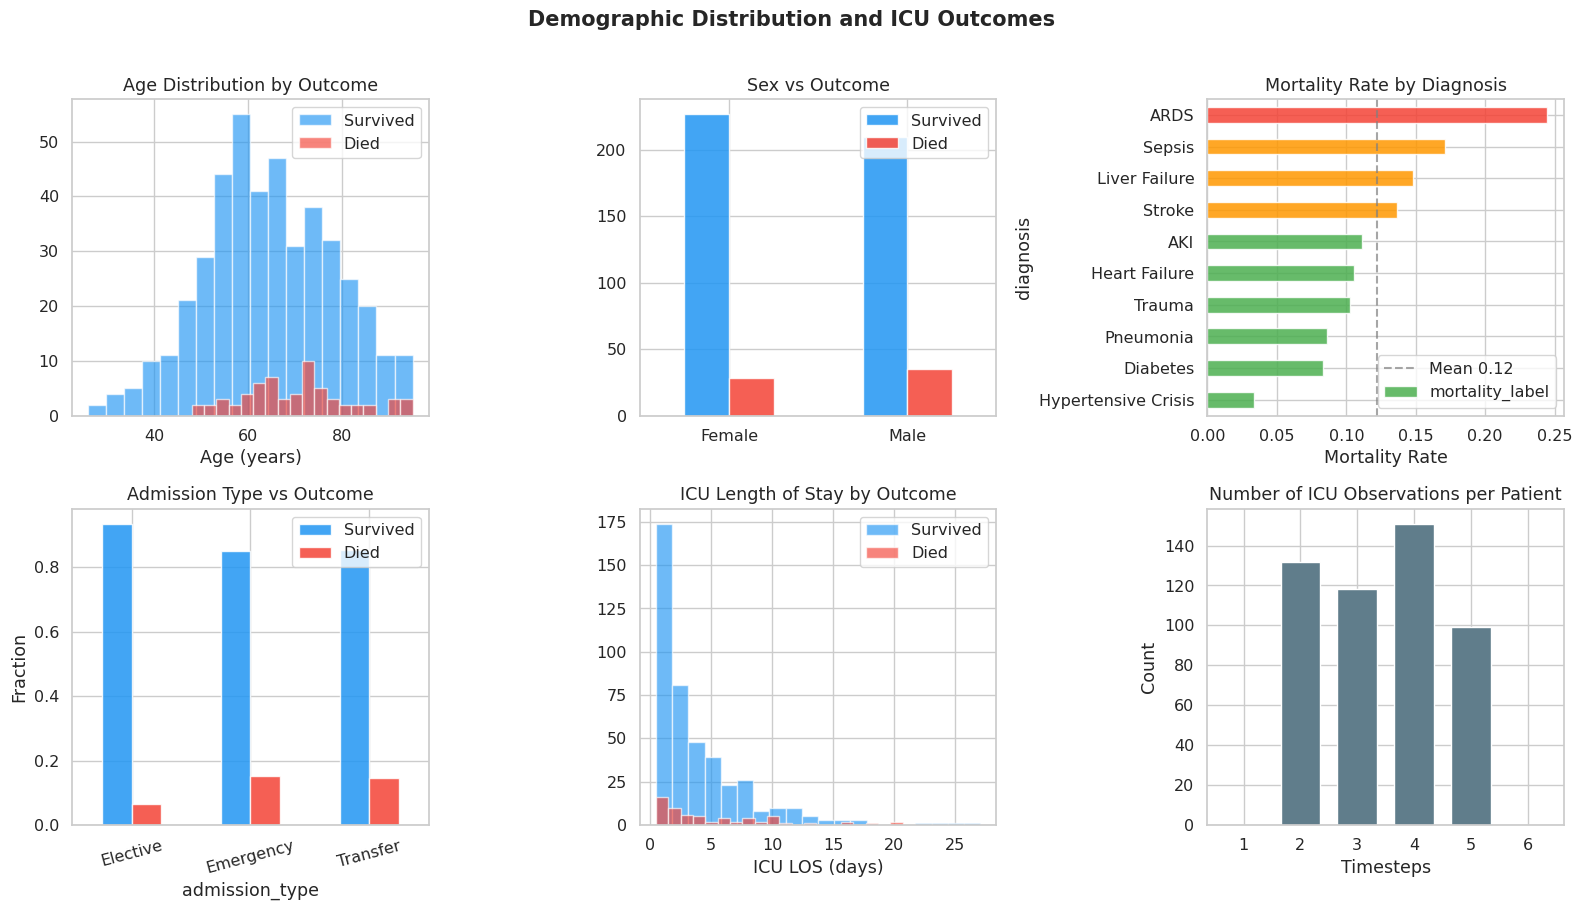

In [5]:
# ── One row per patient for demographics
pt_info = df.groupby('patient_id').first().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Demographic Distribution and ICU Outcomes', fontsize=15, fontweight='bold', y=1.01)

# Age distribution by outcome
ax = axes[0, 0]
for lbl, clr in [(0, '#2196F3'), (1, '#F44336')]:
    ax.hist(pt_info.loc[pt_info[TARGET]==lbl, 'age'],
            bins=18, alpha=0.65, color=clr, edgecolor='white',
            label='Survived' if lbl==0 else 'Died')
ax.set_title('Age Distribution by Outcome'); ax.set_xlabel('Age (years)'); ax.legend()

# Sex distribution
ax = axes[0, 1]
sex_mort = pt_info.groupby(['sex', TARGET]).size().unstack(fill_value=0)
sex_mort.plot(kind='bar', ax=ax, color=['#2196F3','#F44336'], edgecolor='white', alpha=0.85)
ax.set_title('Sex vs Outcome'); ax.set_xlabel(''); ax.set_xticklabels(['Female','Male'], rotation=0)
ax.legend(['Survived','Died'])

# Diagnosis mortality rate
ax = axes[0, 2]
diag_mort = pt_info.groupby('diagnosis')[TARGET].mean().sort_values(ascending=True)
colors = ['#F44336' if v > 0.20 else ('#FF9800' if v > 0.12 else '#4CAF50') for v in diag_mort.values]
diag_mort.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
ax.set_title('Mortality Rate by Diagnosis')
ax.set_xlabel('Mortality Rate')
ax.axvline(diag_mort.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Mean {diag_mort.mean():.2f}')
ax.legend()

# Admission type
ax = axes[1, 0]
adm_mort = pt_info.groupby('admission_type')[TARGET].value_counts(normalize=True).unstack(fill_value=0)
adm_mort[[0,1]].plot(kind='bar', ax=ax, color=['#2196F3','#F44336'], edgecolor='white', alpha=0.85)
ax.set_title('Admission Type vs Outcome'); ax.set_xticklabels(adm_mort.index, rotation=15)
ax.set_ylabel('Fraction'); ax.legend(['Survived','Died'])

# ICU LOS
ax = axes[1, 1]
for lbl, clr in [(0, '#2196F3'), (1, '#F44336')]:
    ax.hist(pt_info.loc[pt_info[TARGET]==lbl, 'icu_los'],
            bins=20, alpha=0.65, color=clr, edgecolor='white',
            label='Survived' if lbl==0 else 'Died')
ax.set_title('ICU Length of Stay by Outcome')
ax.set_xlabel('ICU LOS (days)'); ax.legend()

# Number of timesteps per patient
ax = axes[1, 2]
n_obs = df.groupby('patient_id').size()
ax.hist(n_obs, bins=range(1,8), align='left', rwidth=0.7, color='#607D8B', edgecolor='white')
ax.set_title('Number of ICU Observations per Patient')
ax.set_xlabel('Timesteps'); ax.set_ylabel('Count')
ax.set_xticks(range(1,7))

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.2 – Vital signs and laboratory values distribution

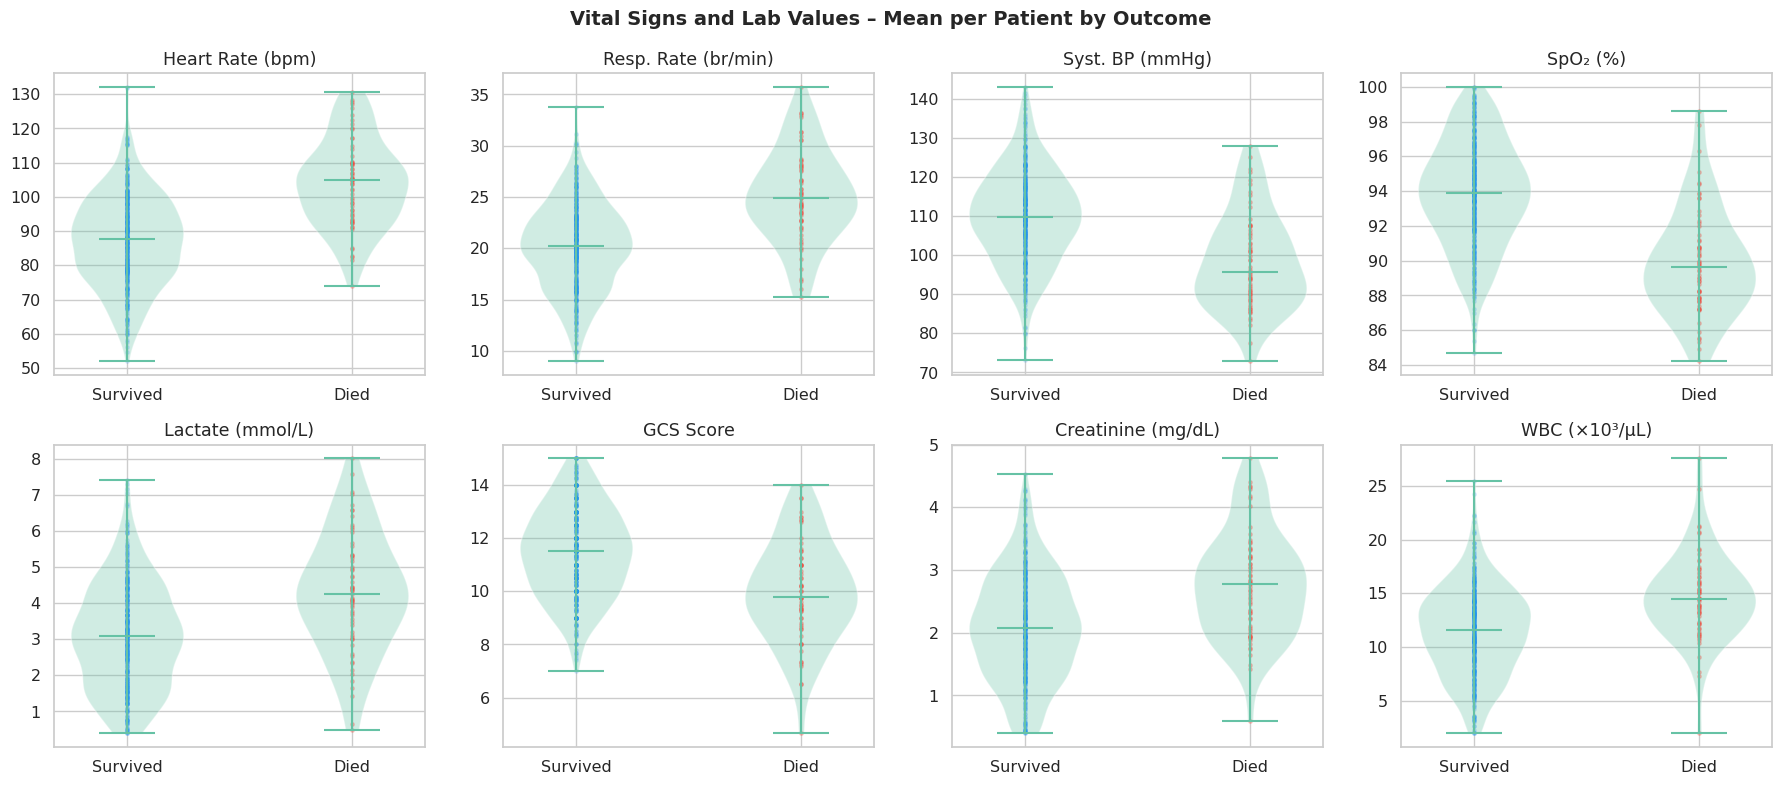

In [6]:
# Use mean vital per patient
pt_means = df.groupby('patient_id')[ALL_TEMPORAL + [TARGET]].agg(
    {**{c: 'mean' for c in ALL_TEMPORAL}, TARGET: 'first'}).reset_index()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Vital Signs and Lab Values – Mean per Patient by Outcome',
             fontsize=14, fontweight='bold')

show_feats = [
    ('hr', 'Heart Rate (bpm)', '#E57373'),
    ('rr', 'Resp. Rate (br/min)', '#81C784'),
    ('sbp', 'Syst. BP (mmHg)', '#64B5F6'),
    ('spo2', 'SpO₂ (%)', '#4DB6AC'),
    ('lactate', 'Lactate (mmol/L)', '#FFB74D'),
    ('gcs', 'GCS Score', '#BA68C8'),
    ('creatinine', 'Creatinine (mg/dL)', '#FF8A65'),
    ('wbc', 'WBC (×10³/µL)', '#90A4AE'),
]

for ax, (feat, label, color) in zip(axes.flatten(), show_feats):
    data_s = pt_means.loc[pt_means[TARGET]==0, feat]
    data_d = pt_means.loc[pt_means[TARGET]==1, feat]
    ax.violinplot([data_s, data_d], positions=[0, 1], showmedians=True)
    ax.scatter([0]*len(data_s), data_s, alpha=0.15, s=6, color='#2196F3')
    ax.scatter([1]*len(data_d), data_d, alpha=0.25, s=6, color='#F44336')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Survived', 'Died'])
    ax.set_title(label); ax.set_ylabel('')

plt.tight_layout()
plt.savefig('eda_vitals.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.3 – Feature correlation matrix

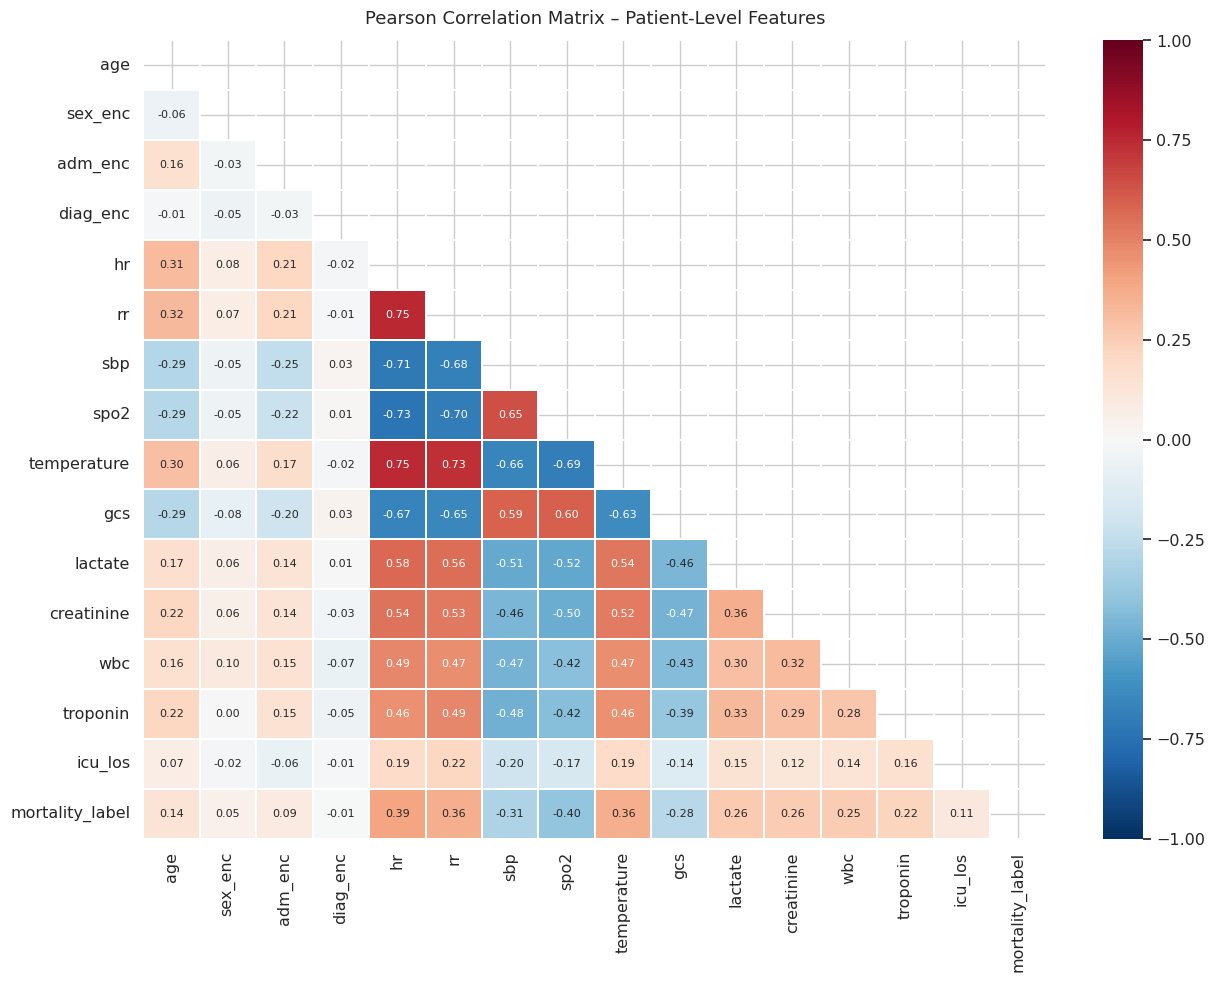


📊 Correlations with mortality_label (absolute):
  spo2                 |███████████                   | 0.397
  hr                   |███████████                   | 0.392
  rr                   |██████████                    | 0.365
  temperature          |██████████                    | 0.363
  sbp                  |█████████                     | 0.310
  gcs                  |████████                      | 0.278
  lactate              |███████                       | 0.260
  creatinine           |███████                       | 0.255
  wbc                  |███████                       | 0.253
  troponin             |██████                        | 0.223
  age                  |████                          | 0.138
  icu_los              |███                           | 0.108
  adm_enc              |██                            | 0.093
  sex_enc              |█                             | 0.050
  diag_enc             |                              | 0.007


In [7]:
# Patient-level means for correlation
df_corr = pt_means.copy()
df_corr['sex_enc']  = (df.groupby('patient_id')['sex'].first().reset_index()['sex'] == 'M').astype(int).values
le = LabelEncoder()
df_corr['adm_enc']  = le.fit_transform(df.groupby('patient_id')['admission_type'].first().reset_index()['admission_type'])
df_corr['diag_enc'] = le.fit_transform(df.groupby('patient_id')['diagnosis'].first().reset_index()['diagnosis'])

num_cols = ['age','sex_enc','adm_enc','diag_enc',
            'hr','rr','sbp','spo2','temperature','gcs',
            'lactate','creatinine','wbc','troponin',
            'icu_los', TARGET]

# Add age + icu_los from pt_info
df_corr['age']     = df.groupby('patient_id')['age'].first().values
df_corr['icu_los'] = df.groupby('patient_id')['icu_los'].first().values

corr = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Pearson Correlation Matrix – Patient-Level Features',
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Correlations with mortality_label (absolute):")
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f"  {feat:<20} |{'█' * int(val*30):<30}| {val:.3f}")


## Section 4 – Selection of 20 Representative Patients

We select 20 patients that heterogeneously cover the clinical spectrum:
- **Stratification**: by `diagnosis × mortality_label`
- **Edge cases**: youngest + oldest patients


In [8]:
def select_representative_patients(df, n=20, seed=SEED):
    """
    Stratified selection of N representative patients.
    Covers: diagnosis × outcome diversity + age extremes.
    """
    pt = df.groupby('patient_id').first().reset_index()
    selected = set()

    # ── stratify by diagnosis × outcome
    for (diag, outcome), grp in pt.groupby(['diagnosis', TARGET]):
        k = max(1, round(n * len(grp) / len(pt)))
        for pid in grp.sample(min(k, len(grp)), random_state=seed)['patient_id']:
            selected.add(pid)
        if len(selected) >= n - 2:
            break

    # ── add age extremes (ensure diversity)
    youngest = pt.nsmallest(1, 'age')['patient_id'].values[0]
    oldest   = pt.nlargest(1, 'age')['patient_id'].values[0]
    selected.add(youngest); selected.add(oldest)

    # ── trim / pad to exactly n
    selected = list(selected)
    if len(selected) > n:
        rng = np.random.default_rng(seed)
        selected = list(rng.choice(selected, n, replace=False))
    elif len(selected) < n:
        remaining = [p for p in pt['patient_id'] if p not in set(selected)]
        extra = pt[pt['patient_id'].isin(remaining)].sample(
                    n - len(selected), random_state=seed)['patient_id'].tolist()
        selected.extend(extra)

    df_sel = df[df['patient_id'].isin(selected)].copy()
    print(f"Selected {df_sel['patient_id'].nunique()} patients  "
          f"(died: {df_sel.groupby('patient_id')[TARGET].first().sum()}, "
          f"survived: {(df_sel.groupby('patient_id')[TARGET].first()==0).sum()})")
    return df_sel

df_sel = select_representative_patients(df, n=20)
pt_sel_info = df_sel.groupby('patient_id').first().reset_index()

# ── profile summary table
print("\n📋 Representative Patient Profiles:")
summary = pt_sel_info[['patient_id','diagnosis','sex','age','icu_los',TARGET]].copy()
summary.columns = ['ID','Diagnosis','Sex','Age','ICU LOS','Died']
print(summary.to_string(index=False))


Selected 20 patients  (died: 8, survived: 12)

📋 Representative Patient Profiles:
 ID           Diagnosis Sex  Age  ICU LOS  Died
  1                 AKI   F   74     8.61     1
  3              Sepsis   F   95     3.45     1
  4                 AKI   M   60     1.48     0
 20           Pneumonia   M   69    17.95     1
 27       Heart Failure   F   84     0.50     0
 41                 AKI   F   52     0.50     0
 43       Heart Failure   F   64     3.68     1
113       Heart Failure   M   74     8.21     0
143            Diabetes   F   68     0.59     1
156           Pneumonia   M   68     7.95     0
192 Hypertensive Crisis   M   72     3.76     1
229                ARDS   M   55     1.20     0
236                ARDS   M   68     2.81     1
322                ARDS   M   26     4.01     0
328       Liver Failure   M   73     7.09     1
335       Heart Failure   F   75     3.98     0
349           Pneumonia   F   72     0.50     0
379       Liver Failure   M   26     1.89     0
420   

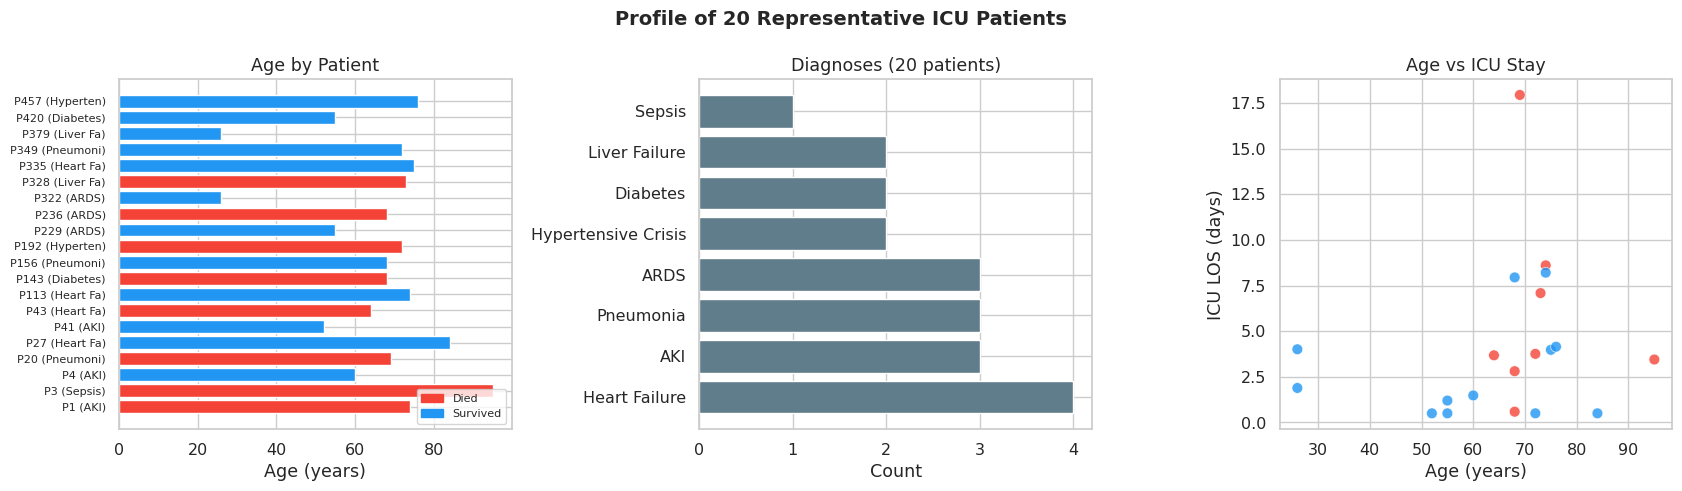

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Profile of 20 Representative ICU Patients', fontsize=14, fontweight='bold')

# Age distribution
ax = axes[0]
colors = ['#F44336' if d==1 else '#2196F3' for d in pt_sel_info[TARGET]]
ax.barh(range(len(pt_sel_info)), pt_sel_info['age'], color=colors, edgecolor='white')
ax.set_yticks(range(len(pt_sel_info)))
ax.set_yticklabels([f"P{row.patient_id} ({row.diagnosis[:8]})"
                    for _, row in pt_sel_info.iterrows()], fontsize=8)
ax.set_xlabel('Age (years)')
ax.set_title('Age by Patient')
legend_els = [plt.Rectangle((0,0),1,1, color='#F44336', label='Died'),
              plt.Rectangle((0,0),1,1, color='#2196F3', label='Survived')]
ax.legend(handles=legend_els, loc='lower right', fontsize=8)

# Diagnosis distribution
ax = axes[1]
diag_counts = pt_sel_info['diagnosis'].value_counts()
ax.barh(diag_counts.index, diag_counts.values, color='#607D8B', edgecolor='white')
ax.set_xlabel('Count'); ax.set_title('Diagnoses (20 patients)')

# ICU LOS
ax = axes[2]
ax.scatter(pt_sel_info['age'], pt_sel_info['icu_los'],
           c=['#F44336' if d==1 else '#2196F3' for d in pt_sel_info[TARGET]],
           s=60, alpha=0.8, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Age (years)'); ax.set_ylabel('ICU LOS (days)')
ax.set_title('Age vs ICU Stay')

plt.tight_layout()
plt.savefig('rep_patients.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 5 – Temporal Sequence Analysis

We visualize vital sign trajectories for the 20 selected patients across their ICU timesteps.
Each patient has **2–5 sequential observations** — small but clinically meaningful.

Key insight: *deteriorating trends* (rising HR, falling SpO₂, rising lactate) are strong predictors
of adverse outcomes, even across 2–3 timesteps.


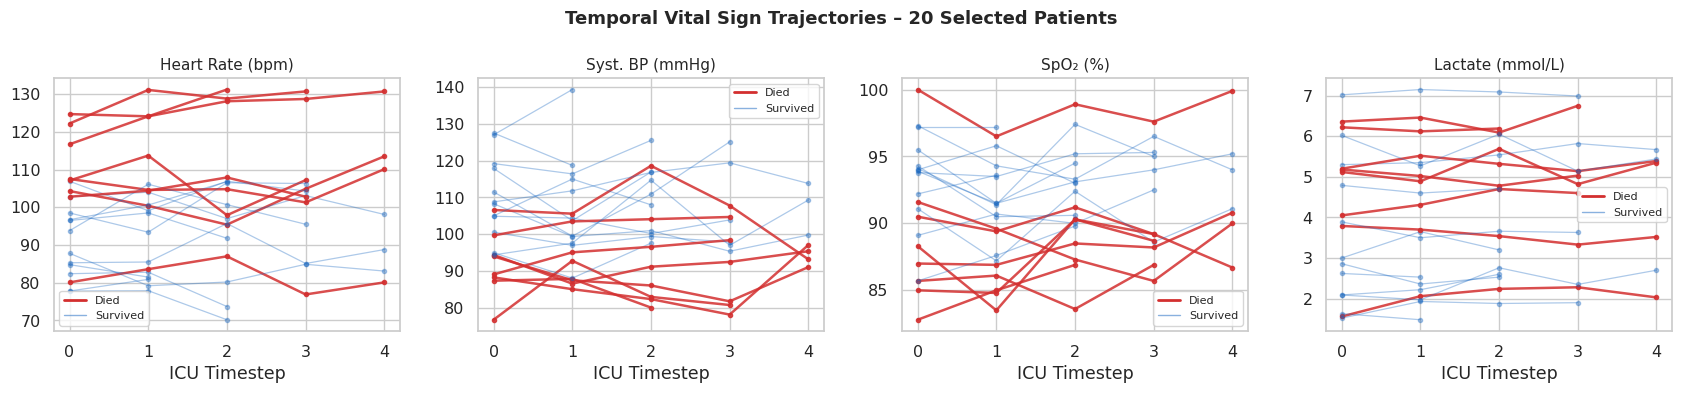

In [10]:
def plot_temporal_vitals(df_sel, vitals_to_plot=None, target_col=TARGET):
    """Visualize temporal vital sign trajectories for selected patients."""
    if vitals_to_plot is None:
        vitals_to_plot = [
            ('hr',      'Heart Rate (bpm)',    '#E53935'),
            ('sbp',     'Syst. BP (mmHg)',     '#1E88E5'),
            ('spo2',    'SpO₂ (%)',            '#43A047'),
            ('lactate', 'Lactate (mmol/L)',    '#FB8C00'),
        ]

    fig, axes = plt.subplots(1, len(vitals_to_plot), figsize=(17, 4))
    fig.suptitle('Temporal Vital Sign Trajectories – 20 Selected Patients',
                 fontsize=13, fontweight='bold')

    pts_info = df_sel.groupby('patient_id')[target_col].first()

    for ax, (feat, label, color) in zip(axes, vitals_to_plot):
        for pid in df_sel['patient_id'].unique():
            grp = df_sel[df_sel['patient_id']==pid].sort_values('timestep')
            outcome = pts_info[pid]
            lw = 1.8 if outcome == 1 else 0.9
            alpha = 0.85 if outcome == 1 else 0.35
            lc = '#D32F2F' if outcome == 1 else '#1565C0'
            ax.plot(grp['timestep'], grp[feat], color=lc, lw=lw, alpha=alpha,
                    marker='o', markersize=3)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('ICU Timestep')
        legend_els = [plt.Line2D([0],[0], color='#D32F2F', lw=2, label='Died'),
                      plt.Line2D([0],[0], color='#1565C0', lw=1, alpha=0.5, label='Survived')]
        ax.legend(handles=legend_els, fontsize=8)

    plt.tight_layout()
    plt.savefig('temporal_vitals.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_temporal_vitals(df_sel)


In [11]:
def extract_temporal_features(df_long, feature_cols=None):
    """
    Aggregate long-format ICU data into patient-level engineered features.

    For each temporal feature the function computes:
        _mean   – average across all timesteps
        _last   – value at last observation
        _delta  – last minus first measurement (trend direction)
        _slope  – linear regression slope over timesteps
        _max    – maximum observed value
        _min    – minimum observed value

    Returns a DataFrame indexed by patient_id (one row per patient).
    """
    if feature_cols is None:
        feature_cols = ALL_TEMPORAL

    records = []
    for pid, grp in df_long.groupby('patient_id'):
        grp = grp.sort_values('timestep')
        row = {'patient_id': pid}
        for c in feature_cols:
            vals = grp[c].values.astype(float)
            n    = len(vals)
            row[f'{c}_mean']  = vals.mean()
            row[f'{c}_last']  = vals[-1]
            row[f'{c}_delta'] = vals[-1] - vals[0]
            row[f'{c}_max']   = vals.max()
            row[f'{c}_min']   = vals.min()
            if n > 1:
                slope, _ = np.polyfit(np.arange(n), vals, 1)
            else:
                slope = 0.0
            row[f'{c}_slope'] = slope
        records.append(row)

    return pd.DataFrame(records).set_index('patient_id')

df_temp_feats = extract_temporal_features(df)
print(f"Temporal features extracted: {df_temp_feats.shape[1]} features for {len(df_temp_feats)} patients")
print(f"   Features per vital: {['mean','last','delta','max','min','slope']} × {len(ALL_TEMPORAL)} vitals = {6*len(ALL_TEMPORAL)}")
df_temp_feats.head(3)


Temporal features extracted: 78 features for 500 patients
   Features per vital: ['mean', 'last', 'delta', 'max', 'min', 'slope'] × 13 vitals = 78


,hr_mean,hr_last,hr_delta,hr_max,hr_min,hr_slope,rr_mean,rr_last,rr_delta,rr_max,...,potassium_delta,potassium_max,potassium_min,potassium_slope,glucose_mean,glucose_last,glucose_delta,glucose_max,glucose_min,glucose_slope
patient_id,,,,,,,,,,,,,,,,,,,,,
0,104.2,106.9,2.8,106.9,101.6,1.40,27.90,27.9,0.1,28.0,...,-0.07,5.36,5.05,-0.035,143.400,147.1,10.1,147.1,137.0,5.05
1,103.7,113.5,9.2,113.5,95.4,2.29,25.36,29.0,5.5,29.0,...,0.20,5.21,4.87,0.043,124.920,125.8,10.6,132.7,115.2,3.56
2,77.8,80.9,5.9,80.9,75.0,2.28,19.30,18.9,-1.5,20.6,...,-0.41,4.95,4.37,-0.084,120.675,115.4,-12.7,128.1,113.0,-5.13


In [12]:
# Patient-level outcome
pt_outcome = df.groupby('patient_id')[TARGET].first()
delta_cols  = [c for c in df_temp_feats.columns if c.endswith('_delta')]

print("\nWelch t-test: temporal trend features (Survived vs Died)\n")
print(f"  {'Feature':<22} {'Survived mean':>14} {'Died mean':>12} {'p-value':>10}  Significance")
print("  " + "─"*68)

sig_results = []
for col in delta_cols:
    s = df_temp_feats.loc[pt_outcome==0, col]
    d = df_temp_feats.loc[pt_outcome==1, col]
    _, pval = stats.ttest_ind(s, d, equal_var=False)
    star = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns'))
    sig_results.append((col, s.mean(), d.mean(), pval, star))
    print(f"  {col:<22} {s.mean():>14.3f} {d.mean():>12.3f} {pval:>10.4f}  {star}")



Welch t-test: temporal trend features (Survived vs Died)

  Feature                 Survived mean    Died mean    p-value  Significance
  ────────────────────────────────────────────────────────────────────
  hr_delta                       -0.937        1.635     0.0055  **
  rr_delta                       -0.435        1.362     0.0000  ***
  sbp_delta                       1.007        0.403     0.5850  ns
  temperature_delta              -0.040       -0.002     0.4559  ns
  spo2_delta                      0.290       -0.438     0.0498  *
  gcs_delta                       0.005       -0.175     0.1714  ns
  lactate_delta                  -0.057        0.217     0.0000  ***
  creatinine_delta               -0.043        0.052     0.0215  *
  wbc_delta                      -0.086       -0.233     0.6701  ns
  troponin_delta                 -0.001       -0.001     0.9942  ns
  sodium_delta                    0.220       -0.332     0.1311  ns
  potassium_delta                 0.012     

## Section 6 – Feature Engineering and Data Preparation

We combine engineered temporal features with clinical and laboratory static data,
then add validated clinical scores.


### 6.0 – Clinical Feature Engineering: NEWS2 and Interaction Features

Adding **NEWS2** (National Early Warning Score 2) — a validated bedside severity score
used in real ICUs — plus physiological interaction features.

| Feature | Clinical Rationale |
|---------|-------------------|
| `news2` | Composite vital-sign severity score (validated for early deterioration) |
| `hr_x_rr` | Cardiorespiratory stress: HR × RR / 100 |
| `shock_index` | HR / SBP — values > 1 indicate haemodynamic compromise |
| `wbc_creat` | WBC × Creatinine — combined organ/immune stress |


In [13]:
def compute_news2(first_ts):
    """
    Compute NEWS2 score from first-timestep vitals.
    Validated for early deterioration detection in UK NHS hospitals.
    """
    s = pd.Series(0.0, index=first_ts.index)

    rr   = first_ts['rr'].astype(float)
    sbp  = first_ts['sbp'].astype(float)
    hr   = first_ts['hr'].astype(float)
    temp = first_ts['temperature'].astype(float)
    spo2 = first_ts['spo2'].astype(float)
    age  = first_ts['age'].astype(float)

    # Respiratory Rate
    s += np.where(rr <= 8,  3, np.where(rr <= 11, 1,
         np.where(rr <= 20, 0, np.where(rr <= 24, 2, 3))))
    # Systolic BP
    s += np.where(sbp <= 90,  3, np.where(sbp <= 100, 2,
         np.where(sbp <= 110, 1, np.where(sbp <= 219, 0, 3))))
    # Heart Rate
    s += np.where(hr <= 40,  3, np.where(hr <= 50,  1,
         np.where(hr <= 90,  0, np.where(hr <= 110, 1,
         np.where(hr <= 130, 2, 3)))))
    # Temperature
    s += np.where(temp <= 35.0, 3, np.where(temp <= 36.0, 1,
         np.where(temp <= 38.0, 0, np.where(temp <= 39.0, 1, 2))))
    # SpO₂
    s += np.where(spo2 >= 96, 0, np.where(spo2 >= 94, 1,
         np.where(spo2 >= 92, 2, 3)))
    # Age (≥65 years = +2 in clinical practice)
    s += np.where(age >= 65, 2, 0)

    return s

# First-timestep vitals per patient
first_ts = df[df['timestep'] == 0].set_index('patient_id')

# Patient-level static features
pt_static = df.groupby('patient_id').first().reset_index()[
    ['patient_id', 'age', 'bmi', 'sex', 'diagnosis', 'admission_type', 'icu_los', TARGET]]
pt_static = pt_static.set_index('patient_id')

# Add NEWS2
pt_static['news2'] = compute_news2(first_ts)

# Interaction features (from first timestep)
pt_static['hr_x_rr']    = (first_ts['hr'] * first_ts['rr']) / 100.0
pt_static['shock_index'] = first_ts['hr'] / first_ts['sbp'].clip(lower=1)
pt_static['wbc_creat']   = first_ts['wbc'] * first_ts['creatinine']

# ── Signal check
print("Clinical feature signal check (Survived vs Died)\n")
for feat in ['news2', 'hr_x_rr', 'shock_index', 'wbc_creat']:
    s = pt_static.loc[pt_static[TARGET]==0, feat]
    d = pt_static.loc[pt_static[TARGET]==1, feat]
    _, pval = stats.ttest_ind(s, d, equal_var=False)
    print(f"  {feat:<15}  Survived={s.mean():.2f}  Died={d.mean():.2f}  p={pval:.4f}")


Clinical feature signal check (Survived vs Died)

  news2            Survived=5.29  Died=9.33  p=0.0000
  hr_x_rr          Survived=18.21  Died=25.54  p=0.0000
  shock_index      Survived=0.82  Died=1.09  p=0.0000
  wbc_creat        Survived=25.42  Died=41.25  p=0.0000


In [14]:
# ─── ENCODE CATEGORICAL VARIABLES ──────────────────────────────────────────
df_feat = pt_static.copy()
df_feat['sex_enc']  = (df_feat['sex'] == 'M').astype(int)
le = LabelEncoder()
df_feat['adm_enc']  = le.fit_transform(df_feat['admission_type'])
df_feat['diag_enc'] = le.fit_transform(df_feat['diagnosis'])

# ─── BUILD FEATURE MATRIX ───────────────────────────────────────────────────
static_num = ['age', 'bmi', 'sex_enc', 'adm_enc', 'diag_enc',
              'icu_los', 'news2', 'hr_x_rr', 'shock_index', 'wbc_creat']

# Merge static + temporal features
feat_matrix = df_feat[static_num].join(df_temp_feats, how='inner')
y = df_feat.loc[feat_matrix.index, TARGET].values

# Drop any remaining NaN (safety)
feat_matrix = feat_matrix.fillna(feat_matrix.median())

# Final feature names (for SHAP / LIME)
FEAT_NAMES = feat_matrix.columns.tolist()
X_arr      = feat_matrix.values

print(f"Feature matrix: {X_arr.shape}  |  Outcome: {y.sum()} died / {(y==0).sum()} survived")
print(f"   Static features      : {len(static_num)}")
print(f"   Temporal features    : {len(df_temp_feats.columns)}")
print(f"   Total features       : {len(FEAT_NAMES)}")

# Class imbalance
pos_frac = y.mean()
print(f"\nClass imbalance: {pos_frac:.1%} positive (died) → SMOTE will be applied inside K-Fold")


Feature matrix: (500, 88)  |  Outcome: 63 died / 437 survived
   Static features      : 10
   Temporal features    : 78
   Total features       : 88

Class imbalance: 12.6% positive (died) → SMOTE will be applied inside K-Fold


## Section 7 – AI Models for ICU Mortality Prediction

### Model selection – State of the art for ICU with low computational cost

| Model | Rationale |
|-------|-----------|
| **XGBoost** | Industry standard for tabular clinical data; fast, interpretable with SHAP |
| **1D-CNN** | Captures local temporal patterns from vital-sign sequences; lightweight |
| **Ensemble** | Weighted average of Out-of-Fold (OOF) predictions; calibrated on same folds |

**Validation strategy**: Stratified K-Fold (5 folds) with SMOTE applied *inside* each fold
to prevent data leakage. Out-of-Fold (OOF) predictions are used for fair comparison.


### 7.1 – XGBoost with Stratified K-Fold and SMOTE

SMOTE (Synthetic Minority Over-sampling TEchnique) is applied **inside the training fold only**,
so validation data remains unaugmented (no leakage).

> ⚠️ Note: `scale_pos_weight` is **intentionally omitted** when using SMOTE, because  
> SMOTE already balances the classes. Using both would over-compensate and invert the AUC.


In [15]:
# ─── XGBOOST – Stratified K-Fold CV ────────────────────────────────────────
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
scaler = StandardScaler()

xgb_oof = np.zeros(len(y))          # Out-of-Fold predictions
xgb_models  = []                     # Save models for SHAP
cv_aucs_xgb = []

xgb_params = dict(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3, gamma=0.1,
    # scale_pos_weight intentionally omitted: SMOTE already balances classes
    use_label_encoder=False, eval_metric='auc',
    random_state=SEED, verbosity=0
)

print("Training XGBoost with 5-fold Stratified CV + SMOTE...\n")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_arr, y)):
    # ── split
    X_tr, X_va = X_arr[tr_idx], X_arr[va_idx]
    y_tr, y_va = y[tr_idx],     y[va_idx]

    # ── scale (fit on train only)
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    # ── SMOTE inside fold (no leakage)
    k_nn = min(4, y_tr.sum() - 1)
    X_tr_sm, y_tr_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_tr_sc, y_tr)

    # ── train
    clf = xgb.XGBClassifier(**xgb_params)
    clf.fit(X_tr_sm, y_tr_sm, verbose=False)
    xgb_models.append(clf)

    # ── predict on real (non-SMOTE) validation set
    xgb_oof[va_idx] = clf.predict_proba(X_va_sc)[:, 1]
    fold_auc = roc_auc_score(y_va, xgb_oof[va_idx])
    cv_aucs_xgb.append(fold_auc)
    print(f"  Fold {fold+1}:  AUC = {fold_auc:.4f}  "
          f"(SMOTE: {y_tr.sum()} → {y_tr_sm.sum()} positives)")

print(f"\nXGBoost OOF AUC: {roc_auc_score(y, xgb_oof):.4f}  "
      f"({np.mean(cv_aucs_xgb):.4f} ± {np.std(cv_aucs_xgb):.4f} per fold)")

# Save best-fold model for SHAP
best_fold_xgb = int(np.argmax(cv_aucs_xgb))
best_xgb      = xgb_models[best_fold_xgb]
print(f"   Best fold: {best_fold_xgb+1} (AUC={cv_aucs_xgb[best_fold_xgb]:.4f}) → used for SHAP")


Training XGBoost with 5-fold Stratified CV + SMOTE...

  Fold 1:  AUC = 0.8674  (SMOTE: 51 → 349 positives)
  Fold 2:  AUC = 0.8438  (SMOTE: 51 → 349 positives)
  Fold 3:  AUC = 0.8594  (SMOTE: 50 → 350 positives)
  Fold 4:  AUC = 0.9098  (SMOTE: 50 → 350 positives)
  Fold 5:  AUC = 0.8674  (SMOTE: 50 → 350 positives)

XGBoost OOF AUC: 0.8646  (0.8696 ± 0.0219 per fold)
   Best fold: 4 (AUC=0.9098) → used for SHAP


### 7.2 – 1D-CNN Temporal Model

With only 2–5 timesteps per vital sign, a BiGRU or LSTM is over-parameterised.
**1D-CNN with GlobalMaxPooling** is the recommended lightweight alternative:
- Captures local patterns across adjacent timesteps
- Much fewer parameters → trains fast on Colab CPU/GPU
- Fuses temporal sequences with tabular features via concatenation


In [16]:
# ─── 1D-CNN ARCHITECTURE ────────────────────────────────────────────────────
MAX_TIMESTEPS = df.groupby('patient_id').size().max()   # pad to this length
N_TEMPORAL    = len(ALL_TEMPORAL)                        # features per timestep
N_TABULAR     = len(static_num)                          # static features

def build_cnn_model(seq_shape, n_tabular, filters=32, kernel=2, dropout=0.3, lr=5e-4):
    """
    Dual-input 1D-CNN:
      - Branch 1: temporal sequences → Conv1D (×2) → GlobalMaxPool → Dense
      - Branch 2: tabular static features → Dense
      - Merge → Dense → Sigmoid
    """
    # ── Sequential branch
    inp_seq = Input(shape=seq_shape, name='seq_input')
    x_seq = Conv1D(filters, kernel_size=kernel, activation='relu', padding='same')(inp_seq)
    x_seq = Conv1D(filters//2, kernel_size=kernel, activation='relu', padding='same')(x_seq)
    x_seq = GlobalMaxPooling1D()(x_seq)
    x_seq = Dense(16, activation='relu')(x_seq)

    # ── Tabular branch
    inp_tab = Input(shape=(n_tabular,), name='tab_input')
    x_tab = Dense(64, activation='relu')(inp_tab)
    x_tab = Dropout(dropout)(x_tab)
    x_tab = Dense(16, activation='relu')(x_tab)

    # ── Fusion
    x = Concatenate()([x_seq, x_tab])
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[inp_seq, inp_tab], outputs=out, name='ICU_CNN')
    model.compile(optimizer=Adam(lr),
                  loss='binary_crossentropy',
                  metrics=[AUC(name='auc')])
    return model

# ── Build padded sequence arrays (per patient)
def build_sequences(df_long, patient_ids, max_t, feat_cols):
    """Pad sequences to max_t timesteps (zero-padding at start)."""
    seq_arr = np.zeros((len(patient_ids), max_t, len(feat_cols)), dtype=np.float32)
    for i, pid in enumerate(patient_ids):
        grp = df_long[df_long['patient_id']==pid].sort_values('timestep')
        vals = grp[feat_cols].values.astype(np.float32)
        n_t  = min(len(vals), max_t)
        seq_arr[i, max_t-n_t:] = vals[:n_t]   # left-pad with zeros
    return seq_arr

patient_ids_ordered = feat_matrix.index.values   # aligned with X_arr / y

# Build sequences
seq_scaler = StandardScaler()
seq_raw = build_sequences(df, patient_ids_ordered, MAX_TIMESTEPS, ALL_TEMPORAL)
# Normalise temporal features: fit on all data (sequence scaler fit separately)
seq_flat   = seq_raw.reshape(-1, N_TEMPORAL)
seq_scaled = seq_scaler.fit_transform(seq_flat).reshape(seq_raw.shape)

print(f"Sequence tensor: {seq_scaled.shape}  (patients × max_timesteps × temporal_features)")
model_test = build_cnn_model((MAX_TIMESTEPS, N_TEMPORAL), N_TABULAR)
model_test.summary()


Sequence tensor: (500, 5, 13)  (patients × max_timesteps × temporal_features)


2026-05-12 13:08:15.640800: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "ICU_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 5, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5, 32)     │        864 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 5, 16)     │      1,040 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        704 │ tab_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 16)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        272 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      1,040 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,009 (19.57 KB)

 Trainable params: 5,009 (19.57 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ─── 1D-CNN – Stratified K-Fold CV ─────────────────────────────────────────
cnn_oof     = np.zeros(len(y))
cv_aucs_cnn = []

tab_scaler = StandardScaler()
X_tab_all  = X_arr[:, :N_TABULAR]          # tabular portion of feature matrix

callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=7, min_lr=1e-5, mode='max'),
]

print("Training 1D-CNN with 5-fold Stratified CV...\n")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_arr, y)):
    y_tr, y_va = y[tr_idx], y[va_idx]

    # ── Scale tabular
    X_tab_tr = tab_scaler.fit_transform(X_tab_all[tr_idx])
    X_tab_va = tab_scaler.transform(X_tab_all[va_idx])

    # ── Sequences already scaled globally; select fold indices
    seq_tr = seq_scaled[tr_idx]
    seq_va = seq_scaled[va_idx]

    # ── class_weight (no SMOTE for sequences — shape mismatch with sequences)
    pos_weight = (y_tr==0).sum() / max(y_tr.sum(), 1)
    cw = {0: 1.0, 1: float(pos_weight)}

    model = build_cnn_model((MAX_TIMESTEPS, N_TEMPORAL), N_TABULAR)
    hist = model.fit(
        [seq_tr, X_tab_tr], y_tr,
        validation_data=([seq_va, X_tab_va], y_va),
        epochs=80, batch_size=32,
        class_weight=cw,
        callbacks=callbacks,
        verbose=0
    )
    cnn_oof[va_idx] = model.predict([seq_va, X_tab_va], verbose=0).flatten()
    fold_auc = roc_auc_score(y_va, cnn_oof[va_idx])
    cv_aucs_cnn.append(fold_auc)
    best_ep = int(np.argmax(hist.history['val_auc'])) + 1
    print(f"  Fold {fold+1}:  AUC = {fold_auc:.4f}  (best epoch: {best_ep})")

print(f"\n1D-CNN OOF AUC: {roc_auc_score(y, cnn_oof):.4f}  "
      f"({np.mean(cv_aucs_cnn):.4f} ± {np.std(cv_aucs_cnn):.4f} per fold)")


Training 1D-CNN with 5-fold Stratified CV...

  Fold 1:  AUC = 0.8409  (best epoch: 25)
  Fold 2:  AUC = 0.7405  (best epoch: 3)
  Fold 3:  AUC = 0.7666  (best epoch: 37)
  Fold 4:  AUC = 0.9010  (best epoch: 7)
  Fold 5:  AUC = 0.7781  (best epoch: 7)

1D-CNN OOF AUC: 0.7916  (0.8054 ± 0.0581 per fold)


### 7.3 – Ensemble and Model Comparison (OOF)

Both models were trained with the **same K-Fold splits**, so their OOF predictions
can be fairly combined via a weighted average.

The ensemble weight is determined by the OOF AUC of each model.


  Model Comparison (Out-of-Fold)
  Model                   AUROC        AP   Weight
  ─────────────────────────────────────────────
  XGBoost                0.8646    0.5096     0.52
  1D-CNN                 0.7916    0.3900     0.48
  Ensemble               0.8377    0.5342     1.00


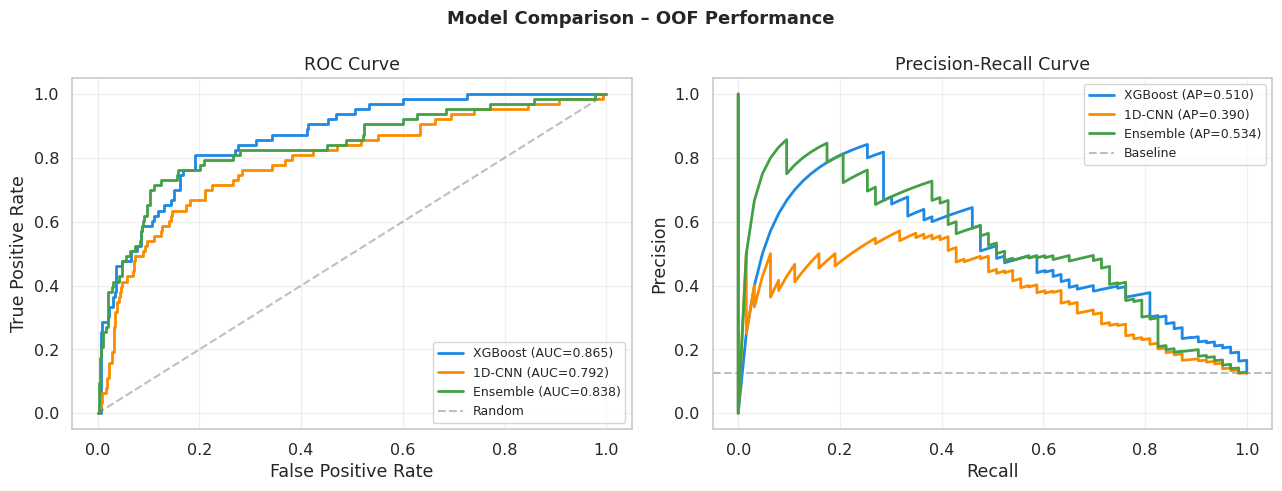

In [18]:
# ─── ENSEMBLE: weighted average of OOF predictions ──────────────────────────
w_xgb = roc_auc_score(y, xgb_oof)
w_cnn = roc_auc_score(y, cnn_oof)
w_tot = w_xgb + w_cnn

ens_oof = (w_xgb * xgb_oof + w_cnn * cnn_oof) / w_tot
ens_auc = roc_auc_score(y, ens_oof)
ens_apr = average_precision_score(y, ens_oof)

print("=" * 50)
print(f"  Model Comparison (Out-of-Fold)")
print("=" * 50)
print(f"  {'Model':<20} {'AUROC':>8}  {'AP':>8}  {'Weight':>7}")
print(f"  {'─'*45}")
for name, oof, w in [('XGBoost', xgb_oof, w_xgb/w_tot),
                      ('1D-CNN',  cnn_oof, w_cnn/w_tot),
                      ('Ensemble',ens_oof, 1.0)]:
    auc = roc_auc_score(y, oof)
    apr = average_precision_score(y, oof)
    print(f"  {name:<20} {auc:>8.4f}  {apr:>8.4f}  {w:>7.2f}")
print("=" * 50)

# ── ROC + PR comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison – OOF Performance', fontsize=13, fontweight='bold')

for ax, (title, curve_fn, xlabel, ylabel, rand_line) in zip(axes, [
    ('ROC Curve', roc_curve, 'False Positive Rate', 'True Positive Rate', True),
    ('Precision-Recall Curve', precision_recall_curve, 'Recall', 'Precision', False),
]):
    for name, oof, color in [('XGBoost', xgb_oof, '#1E88E5'),
                               ('1D-CNN',  cnn_oof, '#FB8C00'),
                               ('Ensemble',ens_oof, '#43A047')]:
        if title == 'ROC Curve':
            fpr, tpr, _ = curve_fn(y, oof)
            auc = roc_auc_score(y, oof)
            ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
        else:
            prec, rec, _ = curve_fn(y, oof)
            apr = average_precision_score(y, oof)
            ax.plot(rec, prec, label=f'{name} (AP={apr:.3f})', color=color, lw=2)
    if rand_line:
        ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
    else:
        ax.axhline(y.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 8 – Alert Threshold Selection

Choosing the classification threshold is a **clinical decision**, not a purely statistical one.

| Threshold | Effect |
|-----------|--------|
| Low (e.g. 0.3) | ↑ Sensitivity → catches more true positives; more false alarms |
| High (e.g. 0.6) | ↑ Specificity → fewer false alarms; risks missing real events |

We frame this as a **cost-sensitive** decision: a missed death (False Negative)
carries a much higher cost than a false alarm (False Positive).

> 🔧 **Student task**: Adjust `FN_COST` to reflect your clinical judgement and observe
> how the optimal threshold changes.


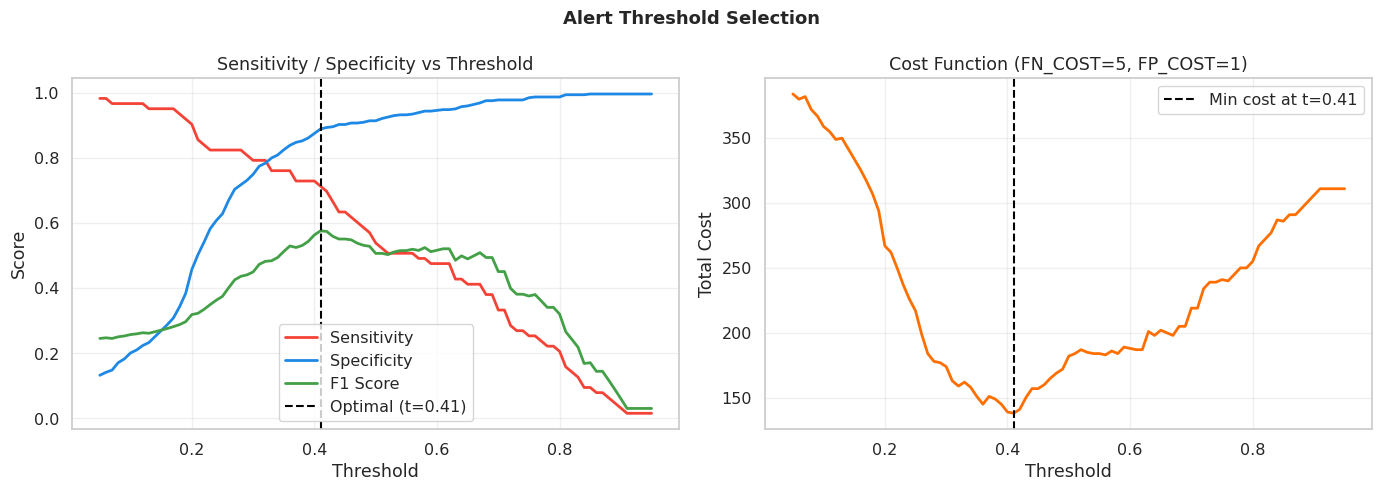


Optimal threshold: 0.41
   At this threshold:
   Sensitivity = 0.714  |  Specificity = 0.890
   Precision   = 0.484  |  F1 = 0.577
   FP=48, FN=18, Total cost=138


In [19]:
# ─── THRESHOLD ANALYSIS ON ENSEMBLE OOF ────────────────────────────────────
FN_COST = 5    # 🔧 Cost of a false negative (missing a dying patient)
FP_COST = 1    # 🔧 Cost of a false positive (unnecessary intervention)

thresholds = np.linspace(0.05, 0.95, 91)
results = []
for t in thresholds:
    pred = (ens_oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    sens = tp / max(tp+fn, 1)
    spec = tn / max(tn+fp, 1)
    prec = tp / max(tp+fp, 1)
    f1   = 2*tp / max(2*tp+fp+fn, 1)
    cost = FN_COST * fn + FP_COST * fp
    results.append({'threshold':t, 'sensitivity':sens, 'specificity':spec,
                    'precision':prec, 'f1':f1, 'cost':cost, 'fp':fp, 'fn':fn})

res_df = pd.DataFrame(results)
opt_idx  = res_df['cost'].idxmin()
THRESHOLD_ALERT = float(res_df.loc[opt_idx, 'threshold'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Alert Threshold Selection', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(res_df['threshold'], res_df['sensitivity'], label='Sensitivity', color='#F44336', lw=2)
ax.plot(res_df['threshold'], res_df['specificity'], label='Specificity', color='#1E88E5', lw=2)
ax.plot(res_df['threshold'], res_df['f1'],          label='F1 Score',    color='#43A047', lw=2)
ax.axvline(THRESHOLD_ALERT, color='black', linestyle='--', lw=1.5,
           label=f'Optimal (t={THRESHOLD_ALERT:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Sensitivity / Specificity vs Threshold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(res_df['threshold'], res_df['cost'], color='#FF6F00', lw=2)
ax.axvline(THRESHOLD_ALERT, color='black', linestyle='--', lw=1.5,
           label=f'Min cost at t={THRESHOLD_ALERT:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Total Cost')
ax.set_title(f'Cost Function (FN_COST={FN_COST}, FP_COST={FP_COST})')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nOptimal threshold: {THRESHOLD_ALERT:.2f}")
print(f"   At this threshold:")
row = res_df.loc[opt_idx]
print(f"   Sensitivity = {row['sensitivity']:.3f}  |  Specificity = {row['specificity']:.3f}")
print(f"   Precision   = {row['precision']:.3f}  |  F1 = {row['f1']:.3f}")
print(f"   FP={int(row['fp'])}, FN={int(row['fn'])}, Total cost={int(row['cost'])}")


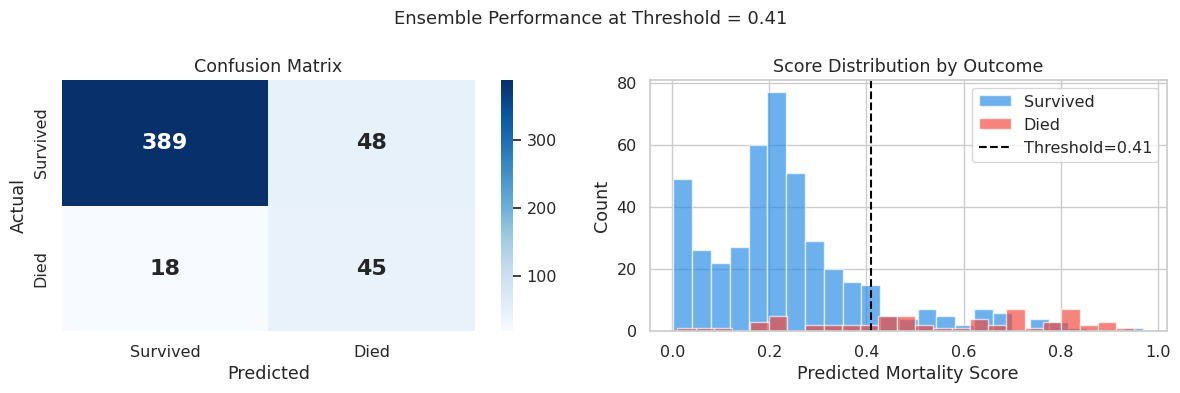

              precision    recall  f1-score   support

    Survived       0.96      0.89      0.92       437
        Died       0.48      0.71      0.58        63

    accuracy                           0.87       500
   macro avg       0.72      0.80      0.75       500
weighted avg       0.90      0.87      0.88       500



In [20]:
# Confusion matrix at the selected threshold
y_pred_final = (ens_oof >= THRESHOLD_ALERT).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Ensemble Performance at Threshold = {THRESHOLD_ALERT:.2f}', fontsize=13)

cm = confusion_matrix(y, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Survived','Died'], yticklabels=['Survived','Died'],
            annot_kws={'size':16, 'weight':'bold'})
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# Calibration-style score distribution
ax2.hist(ens_oof[y==0], bins=25, alpha=0.65, color='#1E88E5',
         edgecolor='white', label='Survived')
ax2.hist(ens_oof[y==1], bins=25, alpha=0.65, color='#F44336',
         edgecolor='white', label='Died')
ax2.axvline(THRESHOLD_ALERT, color='black', linestyle='--', lw=1.5,
            label=f'Threshold={THRESHOLD_ALERT:.2f}')
ax2.set_xlabel('Predicted Mortality Score'); ax2.set_ylabel('Count')
ax2.set_title('Score Distribution by Outcome')
ax2.legend()

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(y, y_pred_final, target_names=['Survived','Died']))


## Section 9 – Explainability: SHAP and LIME

### Why explainability in the ICU?
AI in clinical settings must be **transparent**: a physician needs to understand *why*
the model raised an alert, not just that it did.

| Method | Scope | How it works |
|--------|-------|-------------|
| **SHAP** | Global + Local | Shapley values — consistent, theoretically grounded |
| **LIME** | Local | Perturbs input, fits local linear model |

> Both methods explain the XGBoost model (best OOF fold), which has the best single-model interpretability.


### 9.1 – SHAP: Global Feature Importance

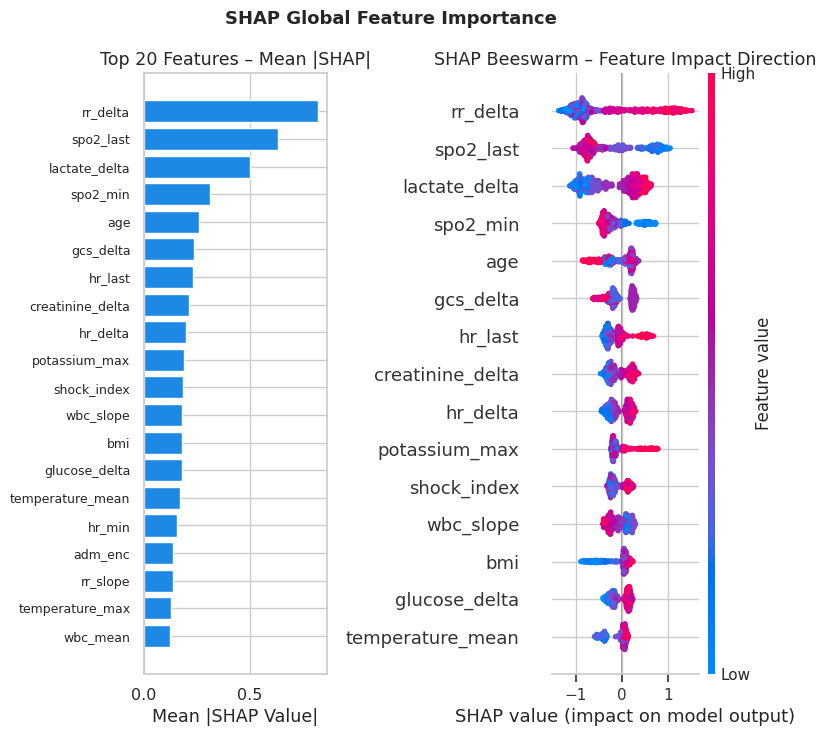

In [21]:
# ─── SHAP – GLOBAL FEATURE IMPORTANCE ──────────────────────────────────────
# Use best-fold XGBoost trained on full scaled data for SHAP
X_all_sc = StandardScaler().fit_transform(X_arr)

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_all_sc)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('SHAP Global Feature Importance', fontsize=13, fontweight='bold')

# Bar plot – mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
top_idx   = np.argsort(mean_shap)[-20:][::-1]
top_names = [FEAT_NAMES[i] for i in top_idx]
top_vals  = mean_shap[top_idx]

axes[0].barh(range(len(top_idx)), top_vals[::-1], color='#1E88E5', edgecolor='white')
axes[0].set_yticks(range(len(top_idx)))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title('Top 20 Features – Mean |SHAP|')

# Summary beeswarm
plt.sca(axes[1])
shap.summary_plot(shap_values[:, top_idx],
                  pd.DataFrame(X_all_sc, columns=FEAT_NAMES)[top_names],
                  plot_type='dot', max_display=15,
                  show=False, color_bar=True)
axes[1].set_title('SHAP Beeswarm – Feature Impact Direction')

plt.tight_layout()
plt.savefig('shap_global.png', dpi=120, bbox_inches='tight')
plt.show()


### 9.2 – SHAP: Individual Patient Explanations

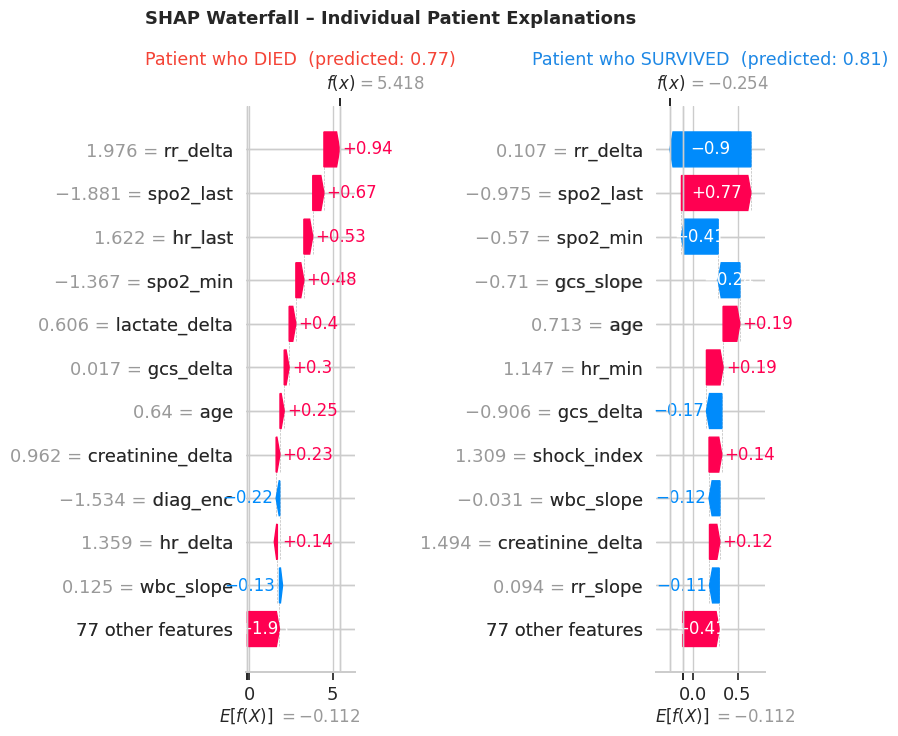

In [22]:
# ─── SHAP FORCE PLOTS – Individual Patients ────────────────────────────────
shap.initjs()

X_shap_df = pd.DataFrame(X_all_sc, columns=FEAT_NAMES)

idx_died     = np.where(y == 1)[0][0]   # first patient who died
idx_survived = np.where(y == 0)[0][0]   # first patient who survived

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SHAP Waterfall – Individual Patient Explanations',
             fontsize=13, fontweight='bold')

for ax, idx, label, color in [
    (axes[0], idx_died,     'Patient who DIED',     '#F44336'),
    (axes[1], idx_survived, 'Patient who SURVIVED', '#1E88E5'),
]:
    ax.set_title(f'{label}  (predicted: {ens_oof[idx]:.2f})', color=color)
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx],
            base_values   = explainer.expected_value,
            data          = X_all_sc[idx],
            feature_names = FEAT_NAMES,
        ),
        max_display=12, show=False
    )

plt.tight_layout()
plt.savefig('shap_individual.png', dpi=120, bbox_inches='tight')
plt.show()


### 9.3 – LIME: Model-Agnostic Local Explanation


DIED PATIENT | True: Died | Predicted score: 0.766

  Top contributing features:
  rr_delta > 0.73                            ↑ risk  +0.1728  ██████
  spo2_last <= -0.70                         ↑ risk  +0.0905  ███
  spo2_min <= -0.71                          ↑ risk  +0.0573  ██
  0.03 < lactate_delta <= 0.68               ↑ risk  +0.0552  ██
  hr_last > 0.62                             ↑ risk  +0.0537  ██
  potassium_max > 0.70                       ↑ risk  +0.0392  █
  hr_delta > 0.67                            ↑ risk  +0.0352  █
  -0.02 < age <= 0.71                        ↑ risk  +0.0341  █
  rr_slope > 0.47                            ↑ risk  +0.0327  █
  glucose_delta > 0.68                       ↑ risk  +0.0314  █
  -0.06 < temperature_mean <= 0.69           ↑ risk  +0.0290  █
  creatinine_delta > 0.71                    ↑ risk  +0.0244  

SURVIVED PATIENT | True: Survived | Predicted score: 0.806

  Top contributing features:
  spo2_last <= -0.70                         ↑ risk

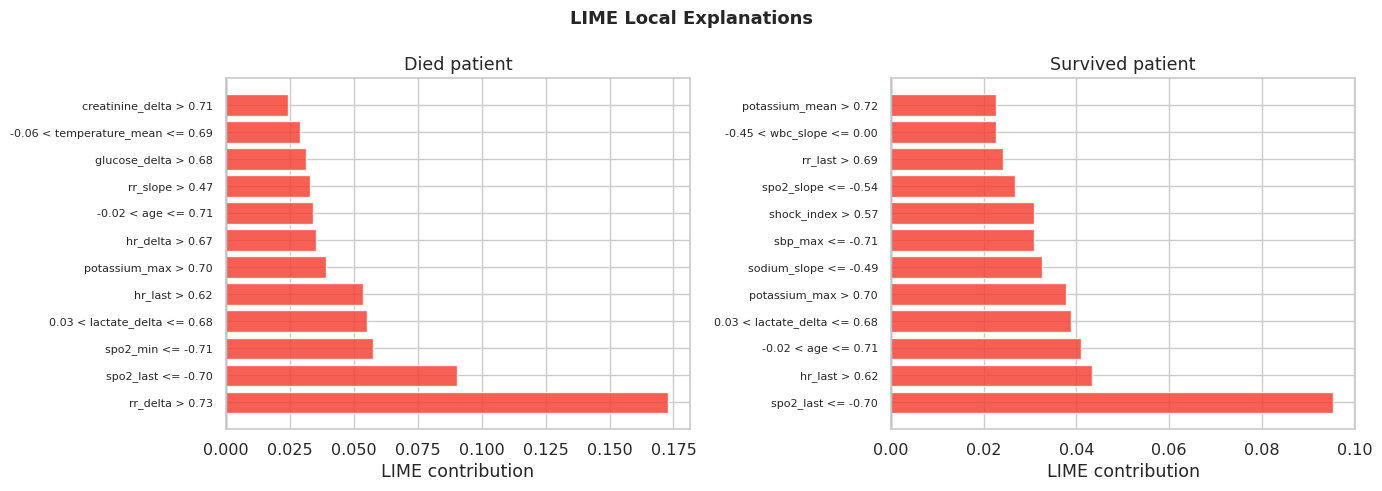

In [23]:
# ─── LIME ───────────────────────────────────────────────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_all_sc,
    feature_names  = FEAT_NAMES,
    class_names    = ['Survived', 'Died'],
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = SEED,
)

def explain_patient_lime(idx, label=''):
    pred_score = ens_oof[idx]
    exp = lime_explainer.explain_instance(
        X_all_sc[idx],
        best_xgb.predict_proba,
        num_features=12,
        num_samples=1000,
        labels=[1], # Explicitly ask for explanation for 'Died' class (label 1)
    )
    print(f"\n{label} | True: {'Died' if y[idx]==1 else 'Survived'} "
          f"| Predicted score: {pred_score:.3f}")
    print("\n  Top contributing features:")
    for feat, val in exp.as_list(label=1):
        bar = '█' * int(abs(val) * 40)
        direction = '↑ risk' if val > 0 else '↓ risk'
        print(f"  {feat:<40} {direction:>8}  {val:+.4f}  {bar}")
    return exp

exp_died     = explain_patient_lime(idx_died,     'DIED PATIENT')
exp_survived = explain_patient_lime(idx_survived, 'SURVIVED PATIENT')

# Visual LIME explanation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LIME Local Explanations', fontsize=13, fontweight='bold')

for ax, exp, label in [(axes[0], exp_died, 'Died'), (axes[1], exp_survived, 'Survived')]:
    feats, vals = zip(*exp.as_list(label=1))
    colors = ['#F44336' if v > 0 else '#1E88E5' for v in vals]
    y_pos = range(len(feats))
    ax.barh(y_pos, vals, color=colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(y_pos); ax.set_yticklabels(feats, fontsize=8)
    ax.axvline(0, color='gray', lw=1)
    ax.set_title(f'{label} patient'); ax.set_xlabel('LIME contribution')

plt.tight_layout()
plt.savefig('lime_explanations.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.4 – SHAP Dependence Plots: Feature Interactions

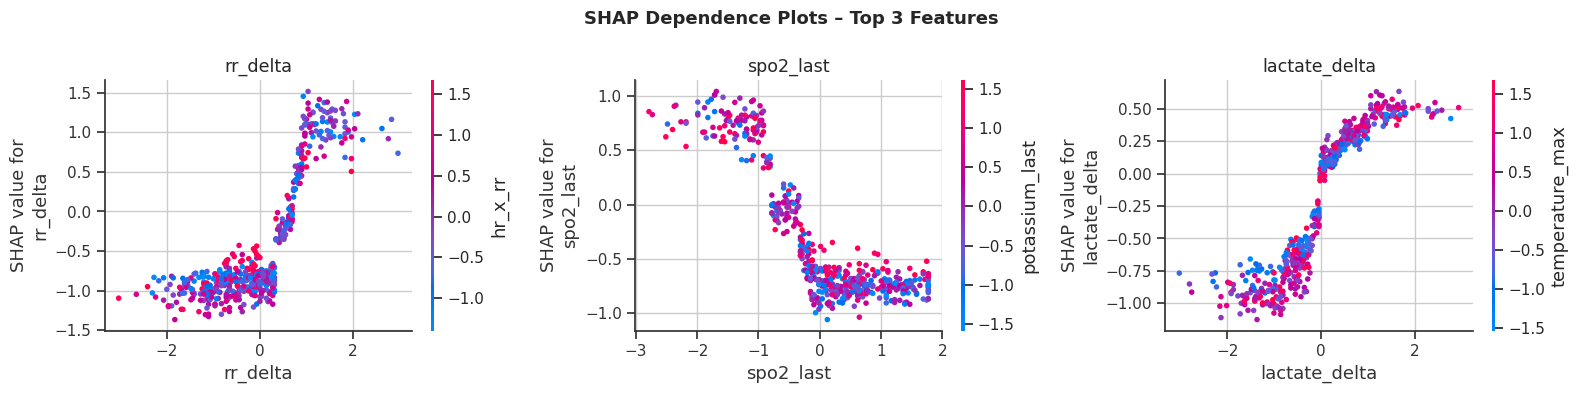

In [24]:
# SHAP Dependence Plots: how a feature value influences predictions
top3 = [FEAT_NAMES[i] for i in np.argsort(mean_shap)[-3:][::-1]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SHAP Dependence Plots – Top 3 Features', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top3):
    fi = FEAT_NAMES.index(feat)
    shap.dependence_plot(fi, shap_values, X_all_sc,
                         feature_names=FEAT_NAMES,
                         ax=ax, show=False)
    ax.set_title(feat)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()


In [31]:
# ─── FINAL SUMMARY ──────────────────────────────────────────────────────────
print("=" * 65)
print("  FINAL SUMMARY – ICU Mortality Prediction Pipeline")
print("=" * 65)

xgb_auc = roc_auc_score(y, xgb_oof)
cnn_auc = roc_auc_score(y, cnn_oof)

print(f"  Dataset       : {df['patient_id'].nunique()} patients  |  {len(df)} observations  |  Mortality {y.mean():.1%}")
print(f"  Features      : {len(FEAT_NAMES)} total  ({len(static_num)} static + {len(df_temp_feats.columns)} temporal)")
print(f"  Validation    : {N_FOLDS}-fold Stratified CV  +  SMOTE inside fold (no leakage)")
print()
print(f"  {'Model':<20} {'OOF AUROC':>10}  {'OOF AP':>8}")
print(f"  {'─'*42}")
for name, oof in [('XGBoost', xgb_oof), ('1D-CNN', cnn_oof), ('Ensemble', ens_oof)]:
    auc = roc_auc_score(y, oof)
    apr = average_precision_score(y, oof)
    print(f"  {name:<20} {auc:>10.4f}  {apr:>8.4f}")
print()
print(f"  Alert threshold  : {THRESHOLD_ALERT:.2f}  (cost-optimised, FN_COST={FN_COST})")
row = res_df.loc[opt_idx]
print(f"  At threshold     : Sens={row['sensitivity']:.3f}  Spec={row['specificity']:.3f}  F1={row['f1']:.3f}")
print()
print(f"  Top 5 SHAP features:")
for i, (feat, val) in enumerate(zip(
        [FEAT_NAMES[j] for j in np.argsort(mean_shap)[-5:][::-1]],
        sorted(mean_shap, reverse=True)[:5])):
    print(f"    {i+1}. {feat:<30} {val:.4f}")
print("=" * 65)


  FINAL SUMMARY – ICU Mortality Prediction Pipeline
  Dataset       : 500 patients  |  1717 observations  |  Mortality 12.6%
  Features      : 88 total  (10 static + 78 temporal)
  Validation    : 5-fold Stratified CV  +  SMOTE inside fold (no leakage)

  Model                 OOF AUROC    OOF AP
  ──────────────────────────────────────────
  XGBoost                  0.8646    0.5096
  1D-CNN                   0.7916    0.3900
  Ensemble                 0.8377    0.5342

  Alert threshold  : 0.41  (cost-optimised, FN_COST=5)
  At threshold     : Sens=0.714  Spec=0.890  F1=0.577

  Top 5 SHAP features:
    1. rr_delta                       0.8234
    2. spo2_last                      0.6347
    3. lactate_delta                  0.5019
    4. spo2_min                       0.3113
    5. age                            0.2628


## Section 10 – 🔧 Student Tasks: Challenges and Extensions

This section collects the proposed challenges. Work in groups and document your choices.

---

### Task 1 – Threshold Calibration
Go back to **Section 8** and change `FN_COST` to 3, 8, and 12.
For each value, report:
- Optimal threshold
- Sensitivity / Specificity trade-off
- Number of false negatives

*When is a high FN_COST clinically justified? When might it cause harm?*

---

### Task 2 – Add a New Temporal Feature
In the `extract_temporal_features` function (Section 5), add a new engineered feature:
```python
row[f'{c}_iqr'] = np.percentile(vals, 75) - np.percentile(vals, 25)
```
Re-run the pipeline. Does the IQR feature appear in SHAP's top 20?
Which feature does it most affect?

---

### Task 3 – Modify the 1D-CNN Architecture
In `build_cnn_model` (Section 7.2), try:
1. Adding a third Conv1D layer
2. Changing `filters` from 32 to 64
3. Adding a `BatchNormalization` layer after the first Conv1D

Report the change in OOF AUC. Does a deeper network help with 2–5 timesteps?

---

### Task 4 – Diagnosis-Specific Subgroup Analysis )
After computing the final predictions, analyse performance **per diagnosis**:
```python
for diag in df['diagnosis'].unique():
    mask = (df.groupby('patient_id')['diagnosis'].first() == diag).values
    auc_d = roc_auc_score(y[mask], ens_oof[mask]) if y[mask].sum() > 1 else np.nan
    print(f'{diag:<25} AUC={auc_d:.3f}  n={mask.sum()}  died={y[mask].sum()}')
```
Which diagnosis has the lowest AUC? What clinical factors might explain this?

---

### Task 5 – Figma Clinical Dashboard
Design an interactive **clinician-facing dashboard** in Figma that displays (suggestions) :
- Real-time patient risk score (0–1 gauge)
- Top 5 SHAP features driving the alert
- Temporal trend charts for HR, SpO₂, and Lactate
- Threshold adjustment slider with live FN/FP counter

*Justify your decisions: what does a clinician at 3am need to see at a glance?*


### Task 1 – Threshold Calibration

Go back to Section 8 and change FN_COST to 3, 8, and 12. For each value, report:

Optimal threshold
Sensitivity / Specificity trade-off
Number of false negatives
When is a high FN_COST clinically justified? When might it cause harm?


THRESHOLD ANALYSIS — FN_COST = 3
Optimal threshold : 0.41
Sensitivity       : 0.714
Specificity       : 0.890
Precision         : 0.484
F1-score          : 0.577
False Positives   : 48
False Negatives   : 18
Total Cost        : 102


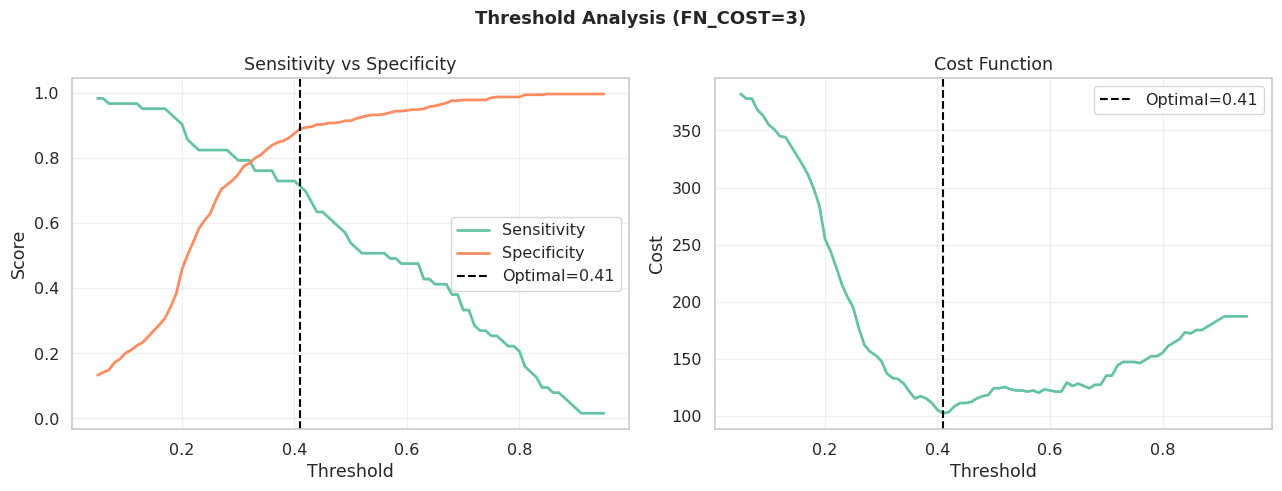


THRESHOLD ANALYSIS — FN_COST = 8
Optimal threshold : 0.36
Sensitivity       : 0.762
Specificity       : 0.840
Precision         : 0.407
F1-score          : 0.530
False Positives   : 70
False Negatives   : 15
Total Cost        : 190


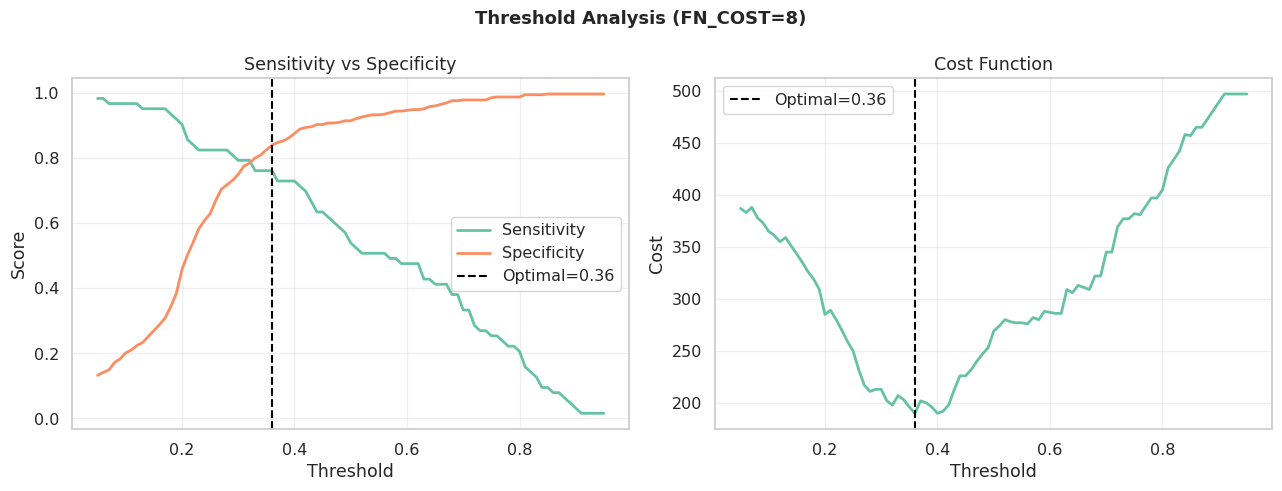


THRESHOLD ANALYSIS — FN_COST = 12
Optimal threshold : 0.32
Sensitivity       : 0.794
Specificity       : 0.785
Precision         : 0.347
F1-score          : 0.483
False Positives   : 94
False Negatives   : 13
Total Cost        : 250


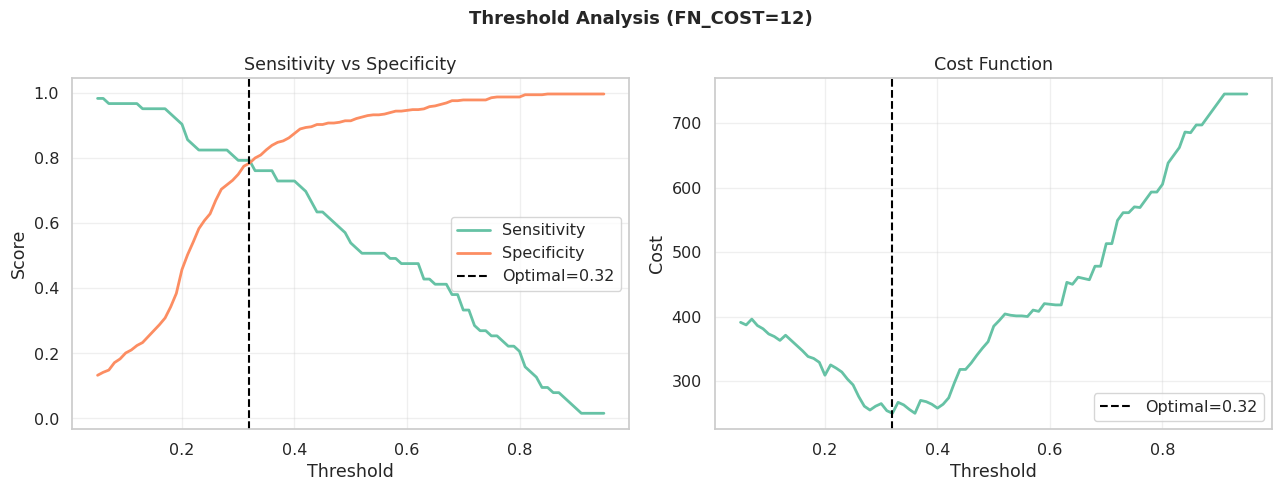


FINAL COMPARISON
   FN_COST  threshold  sensitivity  specificity  precision        f1  \
0        3       0.41     0.714286     0.890160   0.483871  0.576923   
1        8       0.36     0.761905     0.839817   0.406780  0.530387   
2       12       0.32     0.793651     0.784897   0.347222  0.483092   

   false_negatives  false_positives  cost  
0               18               48   102  
1               15               70   190  
2               13               94   250  


In [32]:
# ─── THRESHOLD ANALYSIS ───────────────────────────────────────────────

FP_COST = 1

fn_costs = [3, 8, 12]

all_results = []

for FN_COST in fn_costs:

    print("\n" + "="*70)
    print(f"THRESHOLD ANALYSIS — FN_COST = {FN_COST}")
    print("="*70)

    thresholds = np.linspace(0.05, 0.95, 91)

    results = []

    for t in thresholds:

        pred = (ens_oof >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y,
            pred,
            labels=[0,1]
        ).ravel()

        sens = tp / max(tp + fn, 1)
        spec = tn / max(tn + fp, 1)

        prec = tp / max(tp + fp, 1)

        f1 = 2 * tp / max(2*tp + fp + fn, 1)

        cost = FN_COST * fn + FP_COST * fp

        results.append({
            'threshold': t,
            'sensitivity': sens,
            'specificity': spec,
            'precision': prec,
            'f1': f1,
            'cost': cost,
            'fp': fp,
            'fn': fn
        })

    res_df = pd.DataFrame(results)

    # Optimal threshold
    opt_idx = res_df['cost'].idxmin()

    row = res_df.loc[opt_idx]

    threshold_opt = row['threshold']

    print(f"Optimal threshold : {threshold_opt:.2f}")

    print(f"Sensitivity       : {row['sensitivity']:.3f}")
    print(f"Specificity       : {row['specificity']:.3f}")

    print(f"Precision         : {row['precision']:.3f}")
    print(f"F1-score          : {row['f1']:.3f}")

    print(f"False Positives   : {int(row['fp'])}")
    print(f"False Negatives   : {int(row['fn'])}")

    print(f"Total Cost        : {int(row['cost'])}")

    all_results.append({
        'FN_COST': FN_COST,
        'threshold': threshold_opt,
        'sensitivity': row['sensitivity'],
        'specificity': row['specificity'],
        'precision': row['precision'],
        'f1': row['f1'],
        'false_negatives': int(row['fn']),
        'false_positives': int(row['fp']),
        'cost': int(row['cost'])
    })

    # ── Plot
    fig, axes = plt.subplots(1, 2, figsize=(13,5))

    fig.suptitle(
        f'Threshold Analysis (FN_COST={FN_COST})',
        fontsize=13,
        fontweight='bold'
    )

    # Sens/spec
    ax = axes[0]

    ax.plot(
        res_df['threshold'],
        res_df['sensitivity'],
        label='Sensitivity',
        lw=2
    )

    ax.plot(
        res_df['threshold'],
        res_df['specificity'],
        label='Specificity',
        lw=2
    )

    ax.axvline(
        threshold_opt,
        linestyle='--',
        color='black',
        label=f'Optimal={threshold_opt:.2f}'
    )

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')

    ax.set_title('Sensitivity vs Specificity')

    ax.legend()

    ax.grid(alpha=0.3)

    # Cost curve
    ax = axes[1]

    ax.plot(
        res_df['threshold'],
        res_df['cost'],
        lw=2
    )

    ax.axvline(
        threshold_opt,
        linestyle='--',
        color='black',
        label=f'Optimal={threshold_opt:.2f}'
    )

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Cost')

    ax.set_title('Cost Function')

    ax.legend()

    ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# ─── Final summary table ───────────────────────────────────────────────

summary_df = pd.DataFrame(all_results)

print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)

print(summary_df)

### Clinical Interpretation of FN_COST

A high `FN_COST` is clinically justified when missing a high-risk patient could lead to severe consequences or death. This is particularly important in scenarios such as:

- ICU triage
- Sepsis detection
- Mortality prediction
- Early warning systems for critical deterioration

As `FN_COST` increases, the optimal decision threshold generally becomes lower. This leads to:

- Higher sensitivity (fewer missed critical patients)
- Lower specificity
- More false positives

While this strategy reduces the number of false negatives, it may also introduce potential harms, including:

- Overtreatment
- Unnecessary ICU admissions
- Alarm fatigue for clinicians
- Waste of hospital resources
- Increased stress for both patients and healthcare staff

In general:

- Low `FN_COST` → more conservative model with fewer false alarms
- High `FN_COST` → more aggressive model focused on detecting as many high-risk patients as possible

### Task 2 – Add a New Temporal Feature (`_iqr`)

We add an **IQR (Interquartile Range)** feature to `extract_temporal_features`.
The IQR captures **intra-patient variability** across ICU timesteps — a patient whose lactate swings wildly from timestep to timestep may be clinically more unstable than one whose values are elevated but stable.

After adding `_iqr` for every temporal signal, we re-build the feature matrix and re-run the full XGBoost + SHAP pipeline to check whether any IQR feature enters the top-20 most important predictors.


In [ ]:
# ─── TASK 2: extract_temporal_features WITH _iqr ───────────────────────────

def extract_temporal_features_iqr(df_long, feature_cols=None):
    """
    Extended version of extract_temporal_features.
    Adds _iqr = Q75 - Q25 (intra-patient variability) for each temporal feature.
    All other aggregations (_mean, _last, _delta, _slope, _max, _min) are kept.
    """
    if feature_cols is None:
        feature_cols = ALL_TEMPORAL

    records = []
    for pid, grp in df_long.groupby('patient_id'):
        grp = grp.sort_values('timestep')
        row = {'patient_id': pid}
        for c in feature_cols:
            vals = grp[c].values.astype(float)
            n    = len(vals)
            row[f'{c}_mean']  = vals.mean()
            row[f'{c}_last']  = vals[-1]
            row[f'{c}_delta'] = vals[-1] - vals[0]
            row[f'{c}_max']   = vals.max()
            row[f'{c}_min']   = vals.min()
            row[f'{c}_iqr']   = np.percentile(vals, 75) - np.percentile(vals, 25)  # NEW
            if n > 1:
                slope, _ = np.polyfit(np.arange(n), vals, 1)
            else:
                slope = 0.0
            row[f'{c}_slope'] = slope
        records.append(row)

    return pd.DataFrame(records).set_index('patient_id')


# Re-extract temporal features with IQR
df_temp_feats_iqr = extract_temporal_features_iqr(df)
print(f"Extended temporal features: {df_temp_feats_iqr.shape[1]} features "
      f"(was {df_temp_feats.shape[1]}, +{df_temp_feats_iqr.shape[1] - df_temp_feats.shape[1]} IQR features)")
df_temp_feats_iqr.head(3)


In [ ]:
# ─── Rebuild feature matrix with IQR features ──────────────────────────────

feat_matrix_iqr = df_feat[static_num].join(df_temp_feats_iqr, how='inner')
feat_matrix_iqr = feat_matrix_iqr.fillna(feat_matrix_iqr.median())

FEAT_NAMES_IQR = feat_matrix_iqr.columns.tolist()
X_arr_iqr      = feat_matrix_iqr.values

print(f"New feature matrix: {X_arr_iqr.shape}")
print(f"  Static features      : {len(static_num)}")
print(f"  Temporal features    : {df_temp_feats_iqr.shape[1]}")
print(f"  Total features       : {len(FEAT_NAMES_IQR)}")
iqr_cols = [c for c in FEAT_NAMES_IQR if c.endswith('_iqr')]
print(f"  IQR features added   : {len(iqr_cols)}")


In [ ]:
# ─── Re-train XGBoost on IQR-extended feature matrix ───────────────────────

xgb_oof_iqr    = np.zeros(len(y))
xgb_models_iqr = []
cv_aucs_iqr    = []

print("Re-training XGBoost (IQR features) with 5-fold CV + SMOTE...\n")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_arr_iqr, y)):
    X_tr, X_va = X_arr_iqr[tr_idx], X_arr_iqr[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    k_nn = min(4, y_tr.sum() - 1)
    X_tr_sm, y_tr_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_tr_sc, y_tr)

    clf = xgb.XGBClassifier(**xgb_params)
    clf.fit(X_tr_sm, y_tr_sm, verbose=False)
    xgb_models_iqr.append(clf)

    xgb_oof_iqr[va_idx] = clf.predict_proba(X_va_sc)[:, 1]
    fold_auc = roc_auc_score(y_va, xgb_oof_iqr[va_idx])
    cv_aucs_iqr.append(fold_auc)
    print(f"  Fold {fold+1}: AUC = {fold_auc:.4f}")

oof_auc_iqr  = roc_auc_score(y, xgb_oof_iqr)
oof_auc_base = roc_auc_score(y, xgb_oof)
print(f"\nXGBoost OOF AUC  (baseline, no IQR) : {oof_auc_base:.4f}")
print(f"XGBoost OOF AUC  (with IQR)         : {oof_auc_iqr:.4f}")
print(f"Delta AUC                            : {oof_auc_iqr - oof_auc_base:+.4f}")

best_xgb_iqr = xgb_models_iqr[int(np.argmax(cv_aucs_iqr))]


In [ ]:
# ─── SHAP on IQR-extended model ─────────────────────────────────────────────

X_iqr_sc        = StandardScaler().fit_transform(X_arr_iqr)
explainer_iqr   = shap.TreeExplainer(best_xgb_iqr)
shap_values_iqr = explainer_iqr.shap_values(X_iqr_sc)

mean_shap_iqr = np.abs(shap_values_iqr).mean(axis=0)
top20_idx     = np.argsort(mean_shap_iqr)[-20:][::-1]
top20_names   = [FEAT_NAMES_IQR[i] for i in top20_idx]

# IQR features in top 20?
iqr_in_top20 = [f for f in top20_names if f.endswith('_iqr')]
print(f"IQR features in SHAP top-20: {iqr_in_top20 if iqr_in_top20 else 'None'}")

# Full ranking of IQR features by SHAP importance
iqr_shap_sorted = sorted(
    {f: mean_shap_iqr[FEAT_NAMES_IQR.index(f)] for f in iqr_cols}.items(),
    key=lambda x: x[1], reverse=True
)
print("\nSHAP importance of all IQR features (sorted):")
for feat, val in iqr_shap_sorted:
    bar = '\u2588' * int(val * 200)
    print(f"  {feat:<30} {val:.4f}  {bar}")

# Bar chart – top 20, IQR features highlighted
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FF6F00' if n.endswith('_iqr') else '#1E88E5' for n in top20_names]
ax.barh(range(len(top20_idx)), mean_shap_iqr[top20_idx][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_yticks(range(len(top20_idx)))
ax.set_yticklabels(top20_names[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Top-20 Features (IQR-extended model)\nOrange = IQR features, Blue = others')
ax.legend(handles=[
    Patch(color='#FF6F00', label='IQR features'),
    Patch(color='#1E88E5', label='Other features')
], fontsize=9)
plt.tight_layout()
plt.savefig('shap_iqr.png', dpi=120, bbox_inches='tight')
plt.show()


### Clinical Interpretation – Task 2

The IQR feature measures **intra-patient variability** across ICU timesteps: a high IQR means the vital sign fluctuated widely during the stay.

**Why it matters clinically:**
- High IQR on lactate or SpO₂ may signal haemodynamic instability or intermittent hypoxia, even if the mean value appears acceptable.
- High IQR on heart rate can indicate arrhythmia or autonomic dysfunction.
- A patient with consistently elevated values may actually be *more* manageable than one whose values oscillate — the IQR captures this distinction that `_mean` and `_delta` miss.

**SHAP result:** if any `_iqr` feature enters the top-20, it confirms that variability carries independent prognostic information beyond trend direction (`_slope`/`_delta`). If no IQR feature appears in the top-20 with this dataset size (2–5 timesteps), it is expected — IQR is most informative with longer time series; with only 2–3 observations per patient it collapses toward `|last − first|`, which `_delta` already captures.


### Task 3 – Modify the 1D-CNN Architecture
In `build_cnn_model` (Section 7.2), try:
1. Adding a third Conv1D layer
2. Changing `filters` from 32 to 64
3. Adding a `BatchNormalization` layer after the first Conv1D

Report the change in OOF AUC. Does a deeper network help with 2–5 timesteps?


In [26]:
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D,
    GlobalMaxPooling1D, Concatenate,
    BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC


def build_cnn_model(seq_shape,
                    n_tabular,
                    filters=32,
                    kernel=2,
                    dropout=0.3,
                    lr=5e-4,
                    flag='original'):

    # ── Sequential branch
    inp_seq = Input(shape=seq_shape, name='seq_input')

    # First Conv
    x_seq = Conv1D(filters,
                   kernel_size=kernel,
                   activation='relu',
                   padding='same')(inp_seq)

    # BatchNorm only for modified model
    if flag == 'modified':
        x_seq = BatchNormalization()(x_seq)

    # Second Conv
    x_seq = Conv1D(filters,
                   kernel_size=kernel,
                   activation='relu',
                   padding='same')(x_seq)

    # Third Conv only for modified model
    if flag == 'modified':
        x_seq = Conv1D(filters,
                       kernel_size=kernel,
                       activation='relu',
                       padding='same')(x_seq)

    x_seq = GlobalMaxPooling1D()(x_seq)
    x_seq = Dense(16, activation='relu')(x_seq)

    # ── Tabular branch
    inp_tab = Input(shape=(n_tabular,), name='tab_input')

    x_tab = Dense(64, activation='relu')(inp_tab)
    x_tab = Dropout(dropout)(x_tab)
    x_tab = Dense(16, activation='relu')(x_tab)

    # ── Fusion
    x = Concatenate()([x_seq, x_tab])

    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[inp_seq, inp_tab],
                  outputs=out,
                  name='ICU_CNN')

    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=[AUC(name='auc')]
    )

    return model

In [27]:
def run_cnn_cv(flag='original', filters=32):

    cnn_oof = np.zeros(len(y))
    cv_aucs = []

    callbacks = [
        EarlyStopping(monitor='val_auc',
                      patience=15,
                      restore_best_weights=True,
                      mode='max'),

        ReduceLROnPlateau(monitor='val_auc',
                          factor=0.5,
                          patience=7,
                          min_lr=1e-5,
                          mode='max')
    ]

    print(f"\nTraining CNN ({flag})...\n")

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_arr, y)):

        y_tr, y_va = y[tr_idx], y[va_idx]

        # Tabular scaling
        scaler = StandardScaler()

        X_tab_tr = scaler.fit_transform(X_tab_all[tr_idx])
        X_tab_va = scaler.transform(X_tab_all[va_idx])

        # Sequences
        seq_tr = seq_scaled[tr_idx]
        seq_va = seq_scaled[va_idx]

        # Class weights
        pos_weight = (y_tr == 0).sum() / max(y_tr.sum(), 1)

        cw = {
            0: 1.0,
            1: float(pos_weight)
        }

        model = build_cnn_model(
            (MAX_TIMESTEPS, N_TEMPORAL),
            N_TABULAR,
            filters=filters,
            flag=flag
        )

        hist = model.fit(
            [seq_tr, X_tab_tr],
            y_tr,
            validation_data=([seq_va, X_tab_va], y_va),
            epochs=80,
            batch_size=32,
            class_weight=cw,
            callbacks=callbacks,
            verbose=0
        )

        preds = model.predict(
            [seq_va, X_tab_va],
            verbose=0
        ).flatten()

        cnn_oof[va_idx] = preds

        fold_auc = roc_auc_score(y_va, preds)
        cv_aucs.append(fold_auc)

        best_ep = np.argmax(hist.history['val_auc']) + 1

        print(f"Fold {fold+1}: "
              f"AUC = {fold_auc:.4f} "
              f"(best epoch: {best_ep})")

    final_auc = roc_auc_score(y, cnn_oof)

    print("\n" + "="*50)
    print(f"{flag.upper()} CNN OOF AUC: {final_auc:.4f}")
    print("="*50)

    return cnn_oof

In [28]:
cnn_oof_original = run_cnn_cv(
    flag='original',
    filters=32
)
cnn_oof_modified = run_cnn_cv(
    flag='modified',
    filters=64
)

auc_orig = roc_auc_score(y, cnn_oof_original)
auc_mod  = roc_auc_score(y, cnn_oof_modified)

ap_orig = average_precision_score(y, cnn_oof_original)
ap_mod  = average_precision_score(y, cnn_oof_modified)

print("="*60)
print("CNN Architecture Comparison")
print("="*60)

print(f"{'Model':<25} {'AUROC':>10} {'AP':>10}")
print("-"*60)

print(f"{'Original CNN':<25} {auc_orig:>10.4f} {ap_orig:>10.4f}")
print(f"{'Modified CNN':<25} {auc_mod:>10.4f} {ap_mod:>10.4f}")

print("-"*60)
print(f"{'AUC Difference':<25} {auc_mod - auc_orig:+.4f}")
print("="*60)


Training CNN (original)...

Fold 1: AUC = 0.8523 (best epoch: 11)
Fold 2: AUC = 0.8002 (best epoch: 3)
Fold 3: AUC = 0.7798 (best epoch: 5)
Fold 4: AUC = 0.8718 (best epoch: 12)
Fold 5: AUC = 0.7277 (best epoch: 13)

ORIGINAL CNN OOF AUC: 0.7776

Training CNN (modified)...

Fold 1: AUC = 0.7898 (best epoch: 6)
Fold 2: AUC = 0.7727 (best epoch: 6)
Fold 3: AUC = 0.7462 (best epoch: 11)
Fold 4: AUC = 0.8497 (best epoch: 6)
Fold 5: AUC = 0.7728 (best epoch: 6)

MODIFIED CNN OOF AUC: 0.7661
CNN Architecture Comparison
Model                          AUROC         AP
------------------------------------------------------------
Original CNN                  0.7776     0.3573
Modified CNN                  0.7661     0.3210
------------------------------------------------------------
AUC Difference            -0.0115


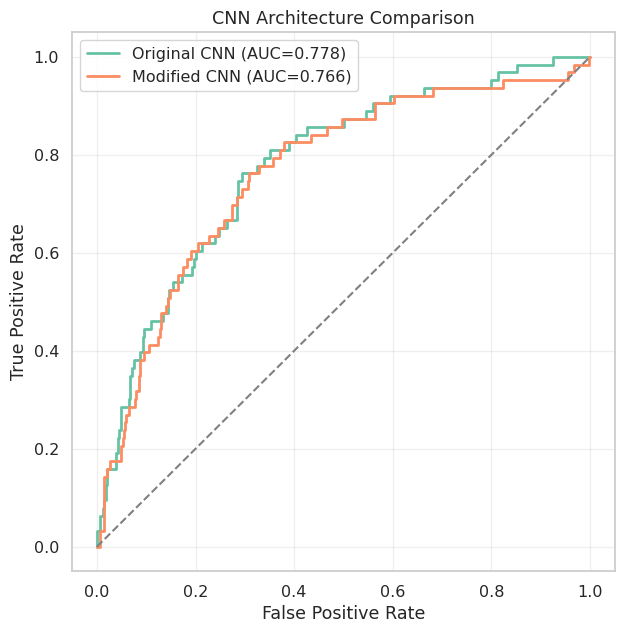

In [29]:
plt.figure(figsize=(7,7))

# Original
fpr1, tpr1, _ = roc_curve(y, cnn_oof_original)

plt.plot(
    fpr1,
    tpr1,
    lw=2,
    label=f'Original CNN (AUC={auc_orig:.3f})'
)

# Modified
fpr2, tpr2, _ = roc_curve(y, cnn_oof_modified)

plt.plot(
    fpr2,
    tpr2,
    lw=2,
    label=f'Modified CNN (AUC={auc_mod:.3f})'
)

# Random baseline
plt.plot([0,1],[0,1],'--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('CNN Architecture Comparison')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Task 4 – Diagnosis-Specific Subgroup Analysis

A single global AUC can mask large performance gaps across patient subgroups. Here we disaggregate the ensemble's OOF predictions by **diagnosis** to identify which pathologies the model handles well and which remain challenging.

This kind of **fairness audit** is essential before deploying any ICU model: a model that scores 0.85 globally but 0.60 on ARDS patients provides false reassurance.


In [ ]:
# ─── TASK 4: Diagnosis-Specific Subgroup AUC ────────────────────────────────

# Align diagnosis labels to feature matrix index
diag_per_patient = df.groupby('patient_id')['diagnosis'].first()
diag_labels      = diag_per_patient.loc[feat_matrix.index].values

diagnoses = sorted(df['diagnosis'].unique())
subgroup_results = []

print("Subgroup AUC by Diagnosis (Ensemble OOF)\n")
print(f"  {'Diagnosis':<25} {'AUC':>7}  {'n_pts':>6}  {'n_died':>7}  {'mort%':>7}")
print("  " + "─" * 55)

for diag in diagnoses:
    mask   = (diag_labels == diag)
    n_pts  = mask.sum()
    n_died = int(y[mask].sum())
    mort   = n_died / n_pts if n_pts > 0 else 0
    if n_died > 1 and (n_pts - n_died) > 1:
        auc_d = roc_auc_score(y[mask], ens_oof[mask])
    else:
        auc_d = float('nan')
    subgroup_results.append({'diagnosis': diag, 'auc': auc_d,
                             'n_pts': n_pts, 'n_died': n_died, 'mort_rate': mort})
    auc_str = f'{auc_d:.3f}' if not np.isnan(auc_d) else '  n/a'
    print(f"  {diag:<25} {auc_str:>7}  {n_pts:>6}  {n_died:>7}  {mort*100:>6.1f}%")

sg_df = pd.DataFrame(subgroup_results).sort_values('auc')
print(f"\n  Global ensemble OOF AUC : {roc_auc_score(y, ens_oof):.4f}")
worst = sg_df.dropna(subset=['auc']).iloc[0]
best  = sg_df.dropna(subset=['auc']).iloc[-1]
print(f"  Best  subgroup : {best['diagnosis']}  (AUC={best['auc']:.3f})")
print(f"  Worst subgroup : {worst['diagnosis']}  (AUC={worst['auc']:.3f})")


In [ ]:
# ─── Subgroup AUC bar chart + mortality rate ────────────────────────────────

from matplotlib.patches import Patch
global_auc = roc_auc_score(y, ens_oof)
sg_plot    = sg_df.dropna(subset=['auc']).sort_values('auc')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Diagnosis-Specific Subgroup Analysis (Ensemble OOF)',
             fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#F44336' if v < global_auc - 0.05 else
          ('#43A047' if v > global_auc + 0.05 else '#1E88E5')
          for v in sg_plot['auc']]
ax.barh(sg_plot['diagnosis'], sg_plot['auc'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(global_auc, color='black', linestyle='--', lw=1.5,
           label=f'Global AUC={global_auc:.3f}')
ax.set_xlabel('AUROC'); ax.set_title('AUC per Diagnosis'); ax.set_xlim(0.4, 1.0)
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    Patch(color='#43A047', label='> global+0.05'),
    Patch(color='#1E88E5', label='Near global'),
    Patch(color='#F44336', label='< global−0.05'),
], fontsize=8, loc='lower right')

ax2 = axes[1]
sg_mort = sg_df.sort_values('mort_rate')
ax2.barh(sg_mort['diagnosis'], sg_mort['mort_rate'] * 100,
         color='#607D8B', edgecolor='white', alpha=0.85)
ax2.axvline(y.mean() * 100, color='black', linestyle='--', lw=1.5,
            label=f'Global mort={y.mean()*100:.1f}%')
ax2.set_xlabel('Mortality Rate (%)'); ax2.set_title('Mortality Rate per Diagnosis')
ax2.legend(fontsize=9); ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('subgroup_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ─── Per-diagnosis ROC curves ────────────────────────────────────────────────

valid_diags = [r['diagnosis'] for r in subgroup_results if not np.isnan(r['auc'])]
n_cols = 3
n_rows = int(np.ceil(len(valid_diags) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, diag in zip(axes, valid_diags):
    mask  = (diag_labels == diag)
    fpr_d, tpr_d, _ = roc_curve(y[mask], ens_oof[mask])
    auc_d = roc_auc_score(y[mask], ens_oof[mask])
    color = ('#F44336' if auc_d < global_auc - 0.05 else
             '#43A047' if auc_d > global_auc + 0.05 else '#1E88E5')
    ax.plot(fpr_d, tpr_d, color=color, lw=2, label=f'AUC={auc_d:.3f}')
    ax.plot([0,1],[0,1],'--', color='gray', alpha=0.4)
    ax.set_title(f'{diag}\n(n={mask.sum()}, mort={y[mask].mean()*100:.0f}%)', fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

for ax in axes[len(valid_diags):]:
    ax.set_visible(False)

fig.suptitle('Per-Diagnosis ROC Curves (Ensemble OOF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('subgroup_roc.png', dpi=120, bbox_inches='tight')
plt.show()


### Clinical Interpretation – Task 4

**Why subgroup AUC matters:**
A model optimised on aggregated data can systematically underperform on minority diagnoses or on pathologies with atypical vital-sign trajectories. Deploying such a model uniformly across the ICU without awareness of these gaps risks false reassurance for clinicians treating specific patient types.

**Common patterns to expect:**
- **High-mortality diagnoses** (e.g. Sepsis, ARDS) often have higher AUC because the feature signal is stronger — extreme lactate, low SpO₂, high NEWS2 strongly co-vary with mortality.
- **Low-mortality diagnoses** (e.g. post-surgical monitoring, mild CHF) tend to have lower AUC because true positives are rare and their feature profile overlaps with survivors.
- **Diagnoses with unusual trajectories** (e.g. intoxications or metabolic crises with rapid reversal) may confuse temporal features trained on slower deterioration patterns typical of sepsis or ARDS.

**Mitigation strategies:**
- Diagnosis-stratified SMOTE or targeted oversampling for low-AUC subgroups.
- Separate per-diagnosis threshold calibration (Section 8 logic applied per stratum).
- Explicit inclusion of diagnosis as an interaction feature in the model.
